# Metals Complex Cumulative Return Normalization

This notebook compares the six-root metals complex (`GC`, `SI`, `HG`, `PL`, `PA`, `ALI`) on the same aligned one-minute continuous futures sample used in the HYP-0011 retest, trimmed to observations from `2020-01-01` onward.

The plot groups are:

1. Raw cumulative log returns by root.
2. Cumulative log returns after ex-ante volatility scaling.
3. Cumulative log returns after volatility scaling and beta hedging against a leave-one-out metals factor.
4. Five-minute Mahalanobis distance over a rolling 30-day lookback for the normalized metals return vectors.
5. Fixed-hold cross-sectional reversion basket backtest using high-Mahalanobis events.
6. State-exit cross-sectional reversion basket backtest that waits for realized reversion.
7. Edge-gated concentrated q95 basket requiring projected reversion to cover at least 3x expected costs.
8. Empirical-forecast concentrated q95 basket requiring historical conditional gross edge to cover at least 3x expected costs.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (13, 6),
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

ROOTS = ["GC", "SI", "HG", "PL", "PA", "ALI"]
DATA_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_1m_10y/continuous")
START_TS = pd.Timestamp("2020-01-01", tz="UTC")

VOL_LOOKBACK_DAYS = 20
BETA_LOOKBACK_DAYS = 63
MIN_VOL_LOOKBACK_BARS = 120
MIN_BETA_LOOKBACK_BARS = 252
MAX_VOL_SCALE = 5.0
PLOT_RESAMPLE = "1D"

MAHALANOBIS_FREQ = "5min"
MAHALANOBIS_WINDOW_DAYS = 30
MAHALANOBIS_MIN_OBS = 500
MAHALANOBIS_RIDGE = 1e-5

CROSS_SECTION_COST_BPS = 1.5
CROSS_SECTION_ENTRY_QUANTILES = [0.95]
CROSS_SECTION_HOLD_BARS = [1, 3, 6, 12]
CROSS_SECTION_EXIT_QUANTILE = 0.50
CROSS_SECTION_REVERSION_TARGETS = [0.25, 0.50, 1.00]
CROSS_SECTION_STOP_FRACTION = 1.00

CONCENTRATED_TOP_PER_SIDE = 1
CONCENTRATED_EDGE_COST_MULTIPLE = 3.0
CONCENTRATED_TARGET_FRACTION = 1.0

EMPIRICAL_FORECAST_BARS = 12
EMPIRICAL_LOOKBACK_DAYS = 730
EMPIRICAL_EDGE_BUCKETS = [0.0, 3.0, 5.0, 10.0, 20.0, np.inf]
EMPIRICAL_MIN_PAIR_BUCKET = 20
EMPIRICAL_MIN_BUCKET = 50
EMPIRICAL_MIN_GLOBAL = 100

In [2]:
def load_root(root: str) -> pd.Series:
    path = DATA_DIR / f"{root}.parquet"
    frame = pd.read_parquet(path, columns=["ts", "cont_logprice"])
    return (
        frame.dropna(subset=["cont_logprice"])
        .drop_duplicates("ts", keep="last")
        .sort_values("ts")
        .set_index("ts")["cont_logprice"]
        .rename(root)
    )


def infer_median_bars_per_day(index: pd.DatetimeIndex) -> int:
    counts = pd.Series(1, index=index).groupby(index.normalize()).sum()
    return max(1, int(round(counts.median())))


def daily_plot_sample(frame: pd.DataFrame) -> pd.DataFrame:
    sampled = frame.resample(PLOT_RESAMPLE).last().ffill()
    return sampled.dropna(how="all")


def plot_cumulative_paths(frame: pd.DataFrame, title: str, ylabel: str) -> None:
    plot_frame = daily_plot_sample(frame)
    fig, axis = plt.subplots(figsize=(13, 6))
    for root in ROOTS:
        axis.plot(plot_frame.index, plot_frame[root], linewidth=1.5, label=root)
    axis.axhline(0.0, color="black", linewidth=1.0, alpha=0.8)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.xaxis.set_major_locator(mdates.YearLocator(1))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axis.legend(ncol=6, loc="upper left")
    fig.tight_layout()
    plt.show()

In [3]:
raw_price_panel = pd.concat([load_root(root) for root in ROOTS], axis=1, join="inner").sort_index()
price_panel = raw_price_panel.loc[raw_price_panel.index >= START_TS].copy()
returns = price_panel.diff().dropna(how="all")

bars_per_day = infer_median_bars_per_day(returns.index)
vol_lookback = max(MIN_VOL_LOOKBACK_BARS, bars_per_day * VOL_LOOKBACK_DAYS)
beta_lookback = max(MIN_BETA_LOOKBACK_BARS, bars_per_day * BETA_LOOKBACK_DAYS)

coverage = pd.DataFrame(
    {
        "first_ts": price_panel.apply(lambda col: col.first_valid_index()),
        "last_ts": price_panel.apply(lambda col: col.last_valid_index()),
        "observations": price_panel.notna().sum(),
        "raw_cum_log_return": returns.sum(),
    }
).loc[ROOTS]

display(
    pd.DataFrame(
        {
            "requested_start_ts": [START_TS],
            "common_first_ts": [price_panel.index.min()],
            "common_last_ts": [price_panel.index.max()],
            "common_observations": [len(price_panel)],
            "median_common_bars_per_day": [bars_per_day],
            "vol_lookback_bars": [vol_lookback],
            "beta_lookback_bars": [beta_lookback],
        }
    )
)
display(coverage)

,requested_start_ts,common_first_ts,common_last_ts,common_observations,median_common_bars_per_day,vol_lookback_bars,beta_lookback_bars
0,2020-01-01 00:00:00+00:00,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,38,760,2394


,first_ts,last_ts,observations,raw_cum_log_return
GC,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,0.727674
SI,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,1.044110
HG,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,0.652543
PL,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,0.358066
PA,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,-0.578635
ALI,2020-01-03 10:06:00+00:00,2026-06-19 16:58:00+00:00,100143,0.434986


## 1. Raw Cumulative Log Returns

This is the direct cumulative log return path for each root on the common timestamp panel. The chart is resampled to daily marks for readability; the cumulative paths are computed from the aligned one-minute continuous log-price differences.

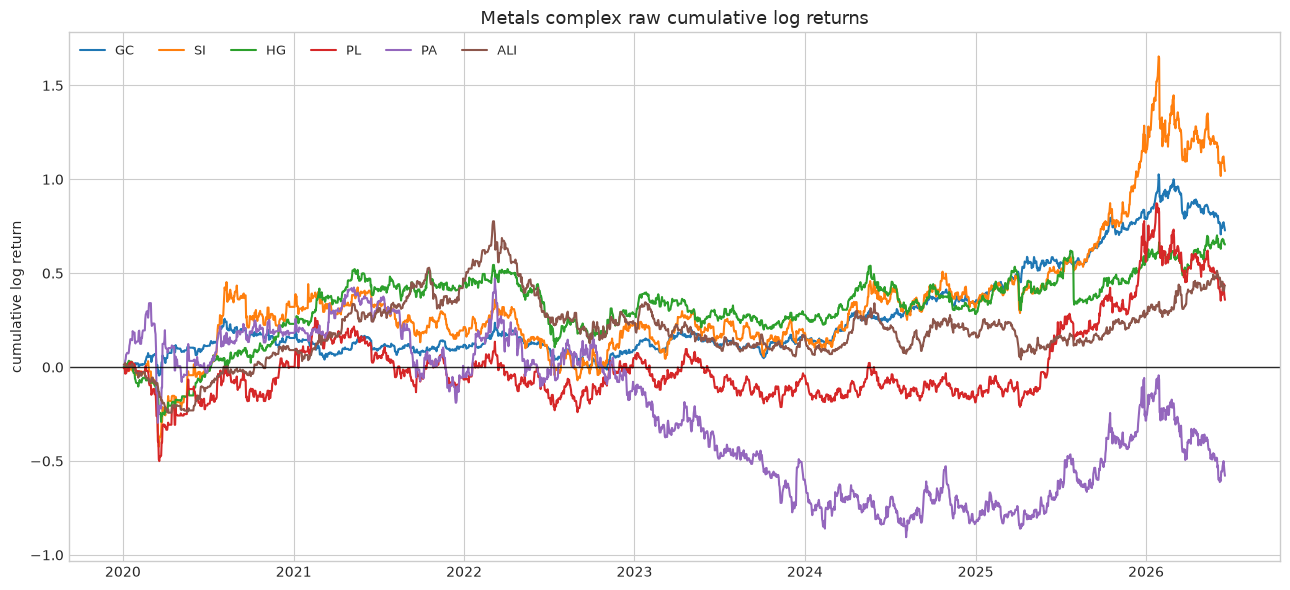

In [4]:
raw_cum_log_returns = returns.cumsum()

plot_cumulative_paths(
    raw_cum_log_returns,
    "Metals complex raw cumulative log returns",
    "cumulative log return",
)

## 2. Volatility-Adjusted Cumulative Log Returns

Each root's one-minute log return is scaled by `median_complex_bar_vol / rolling_root_bar_vol`, using a shifted rolling volatility estimate. The scale is capped at 5x to avoid unstable weights during very low-volatility windows.

,target_bar_vol,median_scale,p95_scale,max_scale
0,0.001555,1.0,2.154044,2.777302


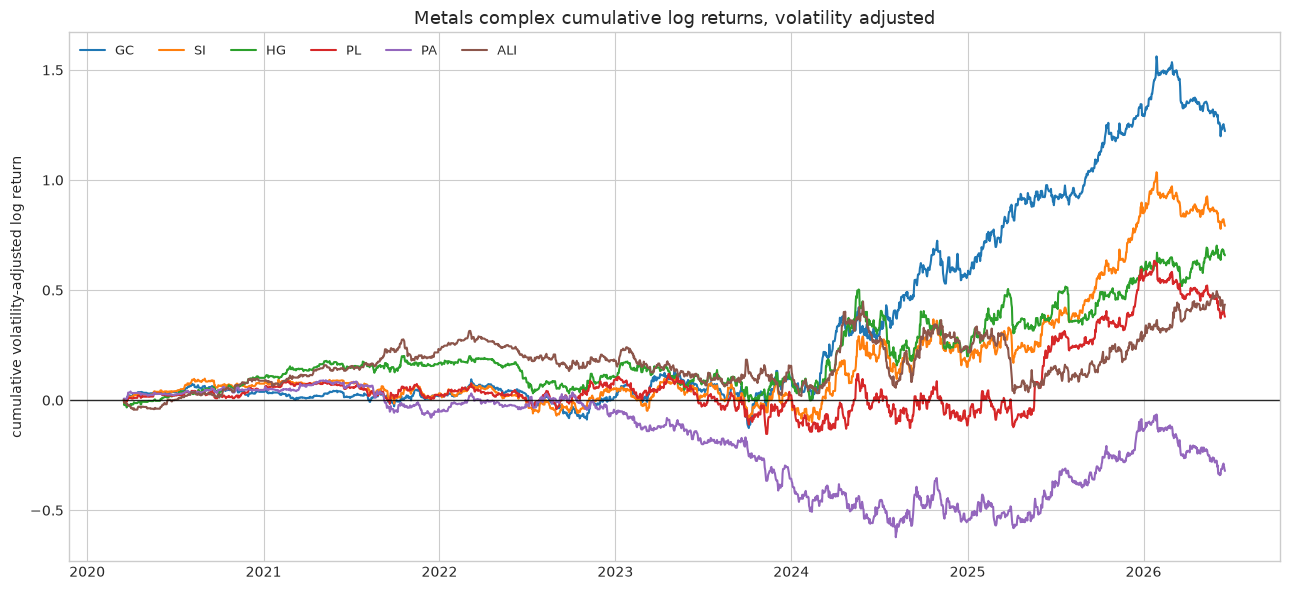

In [5]:
rolling_vol = returns.rolling(vol_lookback, min_periods=vol_lookback // 2).std().shift(1)
vol_floor = rolling_vol.quantile(0.05)
rolling_vol = rolling_vol.clip(lower=vol_floor, axis=1)

target_bar_vol = float(rolling_vol.stack().median())
vol_scale = (target_bar_vol / rolling_vol).clip(upper=MAX_VOL_SCALE)
vol_adjusted_returns = (returns * vol_scale).dropna(how="all")
vol_adjusted_cum_log_returns = vol_adjusted_returns.cumsum()

display(
    pd.DataFrame(
        {
            "target_bar_vol": [target_bar_vol],
            "median_scale": [float(vol_scale.stack().median())],
            "p95_scale": [float(vol_scale.stack().quantile(0.95))],
            "max_scale": [float(vol_scale.stack().max())],
        }
    )
)

plot_cumulative_paths(
    vol_adjusted_cum_log_returns,
    "Metals complex cumulative log returns, volatility adjusted",
    "cumulative volatility-adjusted log return",
)

## 3. Volatility-Adjusted And Beta-Hedged Cumulative Log Returns

For each root, the hedge factor is the equal-weight average of the other five volatility-adjusted return streams. The beta estimate is rolling and shifted by one bar. The plotted path is the cumulative residual return after subtracting `beta * leave_one_out_factor`.

,mean,std,min,25%,50%,75%,max
GC,0.869,0.104,0.523,0.813,0.880,0.930,1.141
SI,1.008,0.070,0.735,0.975,1.017,1.059,1.197
HG,0.830,0.084,0.503,0.784,0.843,0.892,1.000
PL,0.909,0.076,0.684,0.856,0.907,0.961,1.128
PA,0.734,0.108,0.416,0.654,0.714,0.800,1.055
ALI,0.466,0.074,0.195,0.420,0.466,0.517,0.650


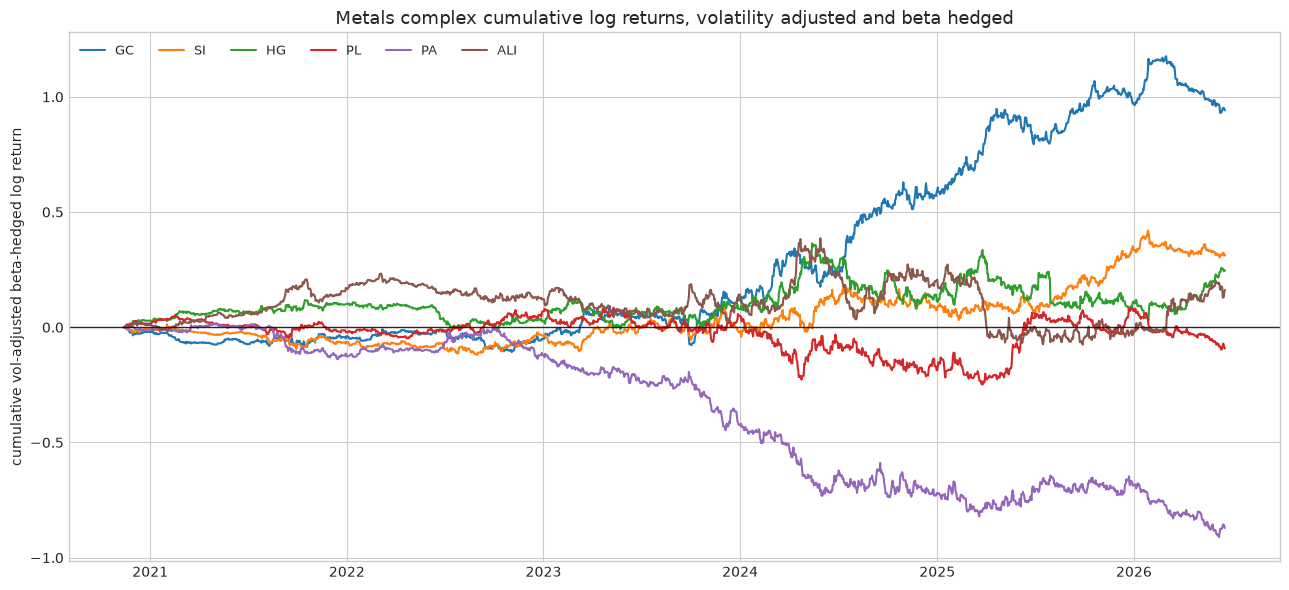

In [6]:
beta_hedged_returns = pd.DataFrame(index=vol_adjusted_returns.index, columns=ROOTS, dtype=float)
beta_panel = pd.DataFrame(index=vol_adjusted_returns.index, columns=ROOTS, dtype=float)

for root in ROOTS:
    asset_returns = vol_adjusted_returns[root]
    factor_returns = vol_adjusted_returns.drop(columns=root).mean(axis=1)
    rolling_cov = (
        asset_returns.rolling(beta_lookback, min_periods=beta_lookback // 2)
        .cov(factor_returns)
        .shift(1)
    )
    rolling_var = (
        factor_returns.rolling(beta_lookback, min_periods=beta_lookback // 2).var().shift(1)
    )
    beta = (rolling_cov / rolling_var.replace(0.0, np.nan)).clip(-3.0, 3.0)
    beta_panel[root] = beta
    beta_hedged_returns[root] = asset_returns - beta * factor_returns

beta_hedged_returns = beta_hedged_returns.dropna(how="all")
beta_hedged_cum_log_returns = beta_hedged_returns.cumsum()

display(beta_panel.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(3))

plot_cumulative_paths(
    beta_hedged_cum_log_returns,
    "Metals complex cumulative log returns, volatility adjusted and beta hedged",
    "cumulative vol-adjusted beta-hedged log return",
)

## 4. Five-Minute Rolling Mahalanobis Distance

This diagnostic turns each five-minute interval into a six-asset return vector and measures how unusual that vector is versus the previous 30 calendar days. The covariance window excludes the current interval, and a small diagonal ridge is added so the inverse covariance is stable when the short rolling sample is noisy.


,first_valid,last_valid,observations,mean,median,p90,p95,p99,max
Vol adjusted,2021-09-30 12:05:00+00:00,2026-06-19 16:55:00+00:00,53982,2.049827,1.705082,3.614852,4.607404,7.334054,37.033193
Vol adjusted + beta hedged,2021-09-30 12:05:00+00:00,2026-06-19 16:55:00+00:00,53982,2.048970,1.703601,3.616450,4.612103,7.323958,37.193038


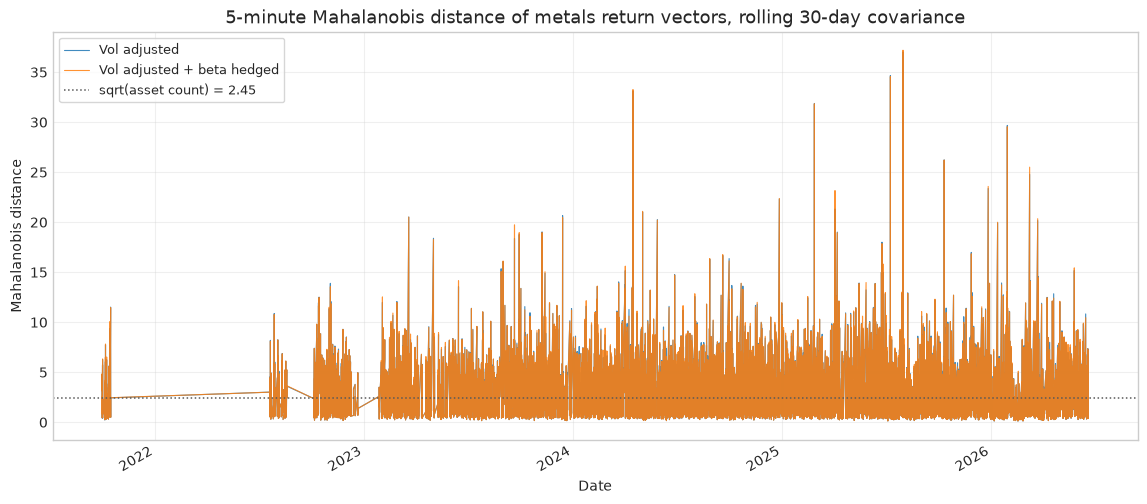

In [7]:
MAHALANOBIS_PANELS = {
    "Vol adjusted": vol_adjusted_returns[ROOTS],
    "Vol adjusted + beta hedged": beta_hedged_returns[ROOTS],
}


def resampled_return_vectors(frame: pd.DataFrame, freq: str = MAHALANOBIS_FREQ) -> pd.DataFrame:
    resampled = (
        frame.reindex(columns=ROOTS)
        .replace([np.inf, -np.inf], np.nan)
        .resample(freq)
        .sum(min_count=1)
        .dropna(how="any")
    )
    return resampled.loc[:, ROOTS]


def rolling_mahalanobis_distance(
    frame: pd.DataFrame,
    *,
    freq: str = MAHALANOBIS_FREQ,
    window_days: int = MAHALANOBIS_WINDOW_DAYS,
    min_obs: int = MAHALANOBIS_MIN_OBS,
    ridge: float = MAHALANOBIS_RIDGE,
) -> pd.Series:
    resampled = resampled_return_vectors(frame, freq=freq)
    values = resampled.to_numpy(dtype=float)
    dates = resampled.index
    window_ns = pd.Timedelta(days=window_days).value
    timestamps = dates.view("int64")
    assets = values.shape[1]
    identity = np.eye(assets)

    prefix_sum = np.vstack([np.zeros((1, assets)), np.cumsum(values, axis=0)])
    outer_values = values[:, :, None] * values[:, None, :]
    prefix_outer = np.concatenate(
        [np.zeros((1, assets, assets)), np.cumsum(outer_values, axis=0)],
        axis=0,
    )

    distances = np.full(len(resampled), np.nan, dtype=float)
    for row, timestamp in enumerate(timestamps):
        start = np.searchsorted(timestamps, timestamp - window_ns, side="left")
        obs = row - start
        if obs < min_obs:
            continue

        window_sum = prefix_sum[row] - prefix_sum[start]
        window_outer = prefix_outer[row] - prefix_outer[start]
        mean = window_sum / obs
        covariance = (window_outer - obs * np.outer(mean, mean)) / (obs - 1)

        diag_scale = float(np.nanmedian(np.diag(covariance)))
        if not np.isfinite(diag_scale) or diag_scale <= 0:
            diag_scale = float(np.nanmean(np.diag(covariance)))
        if not np.isfinite(diag_scale) or diag_scale <= 0:
            diag_scale = 1.0

        covariance = covariance + identity * ridge * diag_scale
        inverse_covariance = np.linalg.pinv(covariance)
        diff = values[row] - mean
        distance_squared = float(diff @ inverse_covariance @ diff)
        distances[row] = np.sqrt(max(distance_squared, 0.0))

    return pd.Series(distances, index=resampled.index, name="mahalanobis_distance")


mahalanobis_distances = pd.DataFrame(
    {
        panel_name: rolling_mahalanobis_distance(panel)
        for panel_name, panel in MAHALANOBIS_PANELS.items()
    }
)

mahalanobis_summary = pd.DataFrame(index=mahalanobis_distances.columns)
for panel_name, distance in mahalanobis_distances.items():
    valid = distance.dropna()
    mahalanobis_summary.loc[panel_name, "first_valid"] = valid.index.min()
    mahalanobis_summary.loc[panel_name, "last_valid"] = valid.index.max()
    mahalanobis_summary.loc[panel_name, "observations"] = len(valid)
    mahalanobis_summary.loc[panel_name, "mean"] = valid.mean()
    mahalanobis_summary.loc[panel_name, "median"] = valid.median()
    mahalanobis_summary.loc[panel_name, "p90"] = valid.quantile(0.90)
    mahalanobis_summary.loc[panel_name, "p95"] = valid.quantile(0.95)
    mahalanobis_summary.loc[panel_name, "p99"] = valid.quantile(0.99)
    mahalanobis_summary.loc[panel_name, "max"] = valid.max()

mahalanobis_summary["observations"] = mahalanobis_summary["observations"].astype(int)
display(mahalanobis_summary)

fig, axis = plt.subplots(figsize=(14, 6))
for panel_name, distance in mahalanobis_distances.items():
    distance = distance.dropna()
    axis.plot(distance.index, distance, linewidth=0.8, alpha=0.85, label=panel_name)

axis.axhline(
    np.sqrt(len(ROOTS)),
    color="0.35",
    linestyle=":",
    linewidth=1.1,
    label=f"sqrt(asset count) = {np.sqrt(len(ROOTS)):.2f}",
)
axis.set_title("5-minute Mahalanobis distance of metals return vectors, rolling 30-day covariance")
axis.set_ylabel("Mahalanobis distance")
axis.set_xlabel("Date")
axis.xaxis.set_major_locator(mdates.YearLocator())
axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axis.legend(loc="upper left", frameon=True)
axis.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.show()

## 5. Fixed-Hold Cross-Sectional Reversion Basket Backtest

This strategy enters only when the five-minute Mahalanobis distance is high versus its own trailing distribution. The basket fades the covariance-adjusted abnormal return vector: assets with unusually positive residual moves are shorted, assets with unusually negative residual moves are bought, and the basket is normalized to one unit of gross exposure. Positions are applied to the next five-minute raw log return and charged `1.5` bps per unit turnover.


In [8]:
def rolling_mahalanobis_state(
    frame: pd.DataFrame,
    *,
    freq: str = MAHALANOBIS_FREQ,
    window_days: int = MAHALANOBIS_WINDOW_DAYS,
    min_obs: int = MAHALANOBIS_MIN_OBS,
    ridge: float = MAHALANOBIS_RIDGE,
) -> tuple[pd.Series, pd.DataFrame]:
    resampled = resampled_return_vectors(frame, freq=freq)
    values = resampled.to_numpy(dtype=float)
    dates = resampled.index
    window_ns = pd.Timedelta(days=window_days).value
    timestamps = dates.view("int64")
    assets = values.shape[1]
    identity = np.eye(assets)

    prefix_sum = np.vstack([np.zeros((1, assets)), np.cumsum(values, axis=0)])
    outer_values = values[:, :, None] * values[:, None, :]
    prefix_outer = np.concatenate(
        [np.zeros((1, assets, assets)), np.cumsum(outer_values, axis=0)],
        axis=0,
    )

    distances = np.full(len(resampled), np.nan, dtype=float)
    scores = np.full_like(values, np.nan, dtype=float)
    for row, timestamp in enumerate(timestamps):
        start = np.searchsorted(timestamps, timestamp - window_ns, side="left")
        obs = row - start
        if obs < min_obs:
            continue

        window_sum = prefix_sum[row] - prefix_sum[start]
        window_outer = prefix_outer[row] - prefix_outer[start]
        mean = window_sum / obs
        covariance = (window_outer - obs * np.outer(mean, mean)) / (obs - 1)

        diag_scale = float(np.nanmedian(np.diag(covariance)))
        if not np.isfinite(diag_scale) or diag_scale <= 0:
            diag_scale = float(np.nanmean(np.diag(covariance)))
        if not np.isfinite(diag_scale) or diag_scale <= 0:
            diag_scale = 1.0

        covariance = covariance + identity * ridge * diag_scale
        inverse_covariance = np.linalg.pinv(covariance)
        diff = values[row] - mean
        score = inverse_covariance @ diff
        distance_squared = float(diff @ score)
        distances[row] = np.sqrt(max(distance_squared, 0.0))
        scores[row] = score - np.nanmean(score)

    distance = pd.Series(distances, index=resampled.index, name="mahalanobis_distance")
    score_frame = pd.DataFrame(scores, index=resampled.index, columns=ROOTS)
    return distance, score_frame


def normalize_signal_weights(score_frame: pd.DataFrame) -> pd.DataFrame:
    raw_weights = -score_frame.sub(score_frame.mean(axis=1), axis=0)
    gross = raw_weights.abs().sum(axis=1)
    return raw_weights.div(gross.where(gross > 0.0), axis=0).fillna(0.0)


def build_event_positions(
    candidate_weights: pd.DataFrame,
    distance: pd.Series,
    entry_threshold: pd.Series,
    exit_threshold: pd.Series,
    hold_bars: int,
) -> tuple[pd.DataFrame, int]:
    position_values = np.zeros(candidate_weights.shape, dtype=float)
    candidate_values = candidate_weights.to_numpy(dtype=float)
    distance_values = distance.reindex(candidate_weights.index).to_numpy(dtype=float)
    entry_values = entry_threshold.reindex(candidate_weights.index).to_numpy(dtype=float)
    exit_values = exit_threshold.reindex(candidate_weights.index).to_numpy(dtype=float)

    current = np.zeros(candidate_weights.shape[1], dtype=float)
    remaining = 0
    entries = 0
    for row in range(len(candidate_weights)):
        active = remaining > 0
        if active and np.isfinite(distance_values[row]) and np.isfinite(exit_values[row]):
            if distance_values[row] < exit_values[row]:
                current = np.zeros_like(current)
                remaining = 0
                active = False

        if remaining <= 0:
            can_enter = (
                np.isfinite(distance_values[row])
                and np.isfinite(entry_values[row])
                and distance_values[row] > entry_values[row]
                and np.isfinite(candidate_values[row]).all()
                and np.abs(candidate_values[row]).sum() > 0.0
            )
            if can_enter:
                current = candidate_values[row].copy()
                remaining = hold_bars
                entries += 1
            else:
                current = np.zeros_like(current)

        position_values[row] = current
        if remaining > 0:
            remaining -= 1

    positions = pd.DataFrame(
        position_values, index=candidate_weights.index, columns=candidate_weights.columns
    )
    return positions, entries


def cross_section_metric_block(
    frame: pd.DataFrame,
    positions: pd.DataFrame,
    entry_quantile: float,
    hold_bars: int,
    entries: int,
) -> dict[str, float | int | str | pd.Timestamp]:
    valid = frame.dropna(subset=["net_return"])
    if valid.empty:
        return {
            "entry_quantile": entry_quantile,
            "hold_bars": hold_bars,
            "entries": entries,
            "observations": 0,
        }

    net = valid["net_return"]
    gross = valid["gross_return"]
    cost = valid["cost_return"]
    turnover = valid["turnover"]
    equity = net.cumsum()
    drawdown = equity - equity.cummax()
    calendar_days = (valid.index[-1] - valid.index[0]).total_seconds() / 86_400.0
    bars_per_year = len(valid) / calendar_days * 365.25 if calendar_days > 0.0 else np.nan
    net_std = net.std(ddof=1)
    sharpe = (
        float(net.mean() / net_std * np.sqrt(bars_per_year))
        if net_std > 0.0 and np.isfinite(bars_per_year)
        else np.nan
    )
    tstat = float(net.mean() / net_std * np.sqrt(len(valid))) if net_std > 0.0 else np.nan
    active = positions.reindex(valid.index).abs().sum(axis=1) > 0.0

    return {
        "entry_quantile": entry_quantile,
        "hold_bars": hold_bars,
        "entries": entries,
        "observations": int(len(valid)),
        "start": valid.index[0],
        "end": valid.index[-1],
        "gross_log_return": float(gross.sum()),
        "cost_log_return": float(cost.sum()),
        "net_log_return": float(net.sum()),
        "compounded_net_return": float(np.expm1(net.sum())),
        "mean_net_bps_per_bar": float(net.mean() * 10_000.0),
        "bar_tstat": tstat,
        "annualized_sharpe": sharpe,
        "max_drawdown_log": float(drawdown.min()),
        "active_fraction": float(active.mean()),
        "avg_turnover": float(turnover.mean()),
        "p95_turnover": float(turnover.quantile(0.95)),
    }


signal_distance, signal_scores = rolling_mahalanobis_state(beta_hedged_returns[ROOTS])
candidate_weights = normalize_signal_weights(signal_scores)
raw_5m_returns = resampled_return_vectors(returns[ROOTS], freq=MAHALANOBIS_FREQ).reindex(
    candidate_weights.index
)
forward_raw_5m_returns = raw_5m_returns.shift(-1)

strategy_frames = []
metric_rows = []
for entry_quantile in CROSS_SECTION_ENTRY_QUANTILES:
    entry_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(entry_quantile)
        .shift(1)
    )
    exit_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(CROSS_SECTION_EXIT_QUANTILE)
        .shift(1)
    )
    for hold_bars in CROSS_SECTION_HOLD_BARS:
        positions, entries = build_event_positions(
            candidate_weights,
            signal_distance,
            entry_threshold,
            exit_threshold,
            hold_bars,
        )
        gross_return = (positions * forward_raw_5m_returns).sum(axis=1)
        turnover = positions.diff().abs().sum(axis=1).fillna(positions.abs().sum(axis=1))
        cost_return = turnover * (CROSS_SECTION_COST_BPS / 10_000.0)
        strategy = pd.DataFrame(
            {
                "entry_quantile": entry_quantile,
                "hold_bars": hold_bars,
                "gross_return": gross_return,
                "cost_return": cost_return,
                "net_return": gross_return - cost_return,
                "turnover": turnover,
                "mahalanobis_distance": signal_distance,
                "entry_threshold": entry_threshold,
                "exit_threshold": exit_threshold,
                "gross_exposure": positions.abs().sum(axis=1),
            }
        ).iloc[:-1]
        first_valid = strategy["entry_threshold"].first_valid_index()
        if first_valid is not None:
            strategy = strategy.loc[first_valid:]
        strategy["variant"] = f"q{entry_quantile:.2f}_hold{hold_bars}"
        strategy_frames.append(strategy)
        metric_rows.append(
            cross_section_metric_block(strategy, positions, entry_quantile, hold_bars, entries)
        )

cross_section_returns = pd.concat(strategy_frames).sort_index()
cross_section_metrics = pd.DataFrame(metric_rows).sort_values("annualized_sharpe", ascending=False)
display(cross_section_metrics)

best_variant = cross_section_metrics.iloc[0]
best_label = f"q{best_variant.entry_quantile:.2f}_hold{int(best_variant.hold_bars)}"
best_returns = cross_section_returns.loc[cross_section_returns["variant"] == best_label].copy()
best_returns["cum_net"] = best_returns["net_return"].cumsum()
best_returns["cum_gross"] = best_returns["gross_return"].cumsum()
best_returns["drawdown"] = best_returns["cum_net"] - best_returns["cum_net"].cummax()

print(f"Best variant by net Sharpe: {best_label}")
print(
    f"Net log return={best_variant.net_log_return:.4f}, "
    f"gross={best_variant.gross_log_return:.4f}, "
    f"cost={best_variant.cost_log_return:.4f}, "
    f"Sharpe={best_variant.annualized_sharpe:.2f}, "
    f"max DD={best_variant.max_drawdown_log:.4f}, "
    f"entries={int(best_variant.entries)}"
)

,entry_quantile,hold_bars,entries,observations,start,end,gross_log_return,cost_log_return,net_log_return,compounded_net_return,mean_net_bps_per_bar,bar_tstat,annualized_sharpe,max_drawdown_log,active_fraction,avg_turnover,p95_turnover
3,0.95,12,1905,53874,2022-10-28 14:25:00+00:00,2026-06-19 15:35:00+00:00,0.383984,0.570900,-0.186916,-0.170486,-0.034695,-1.648812,-0.864037,-0.227731,0.115399,0.070646,1.0
2,0.95,6,1985,53874,2022-10-28 14:25:00+00:00,2026-06-19 15:35:00+00:00,0.353628,0.592201,-0.238573,-0.212249,-0.044284,-2.215509,-1.161007,-0.279031,0.107157,0.073282,1.0
1,0.95,3,2185,53874,2022-10-28 14:25:00+00:00,2026-06-19 15:35:00+00:00,0.398428,0.644720,-0.246291,-0.218305,-0.045716,-2.475878,-1.297450,-0.338739,0.088521,0.079781,1.0
0,0.95,1,2696,53874,2022-10-28 14:25:00+00:00,2026-06-19 15:35:00+00:00,0.355170,0.773277,-0.418107,-0.341708,-0.077608,-5.024168,-2.632846,-0.433000,0.050043,0.095690,1.0


Best variant by net Sharpe: q0.95_hold12
Net log return=-0.1869, gross=0.3840, cost=0.5709, Sharpe=-0.86, max DD=-0.2277, entries=1905


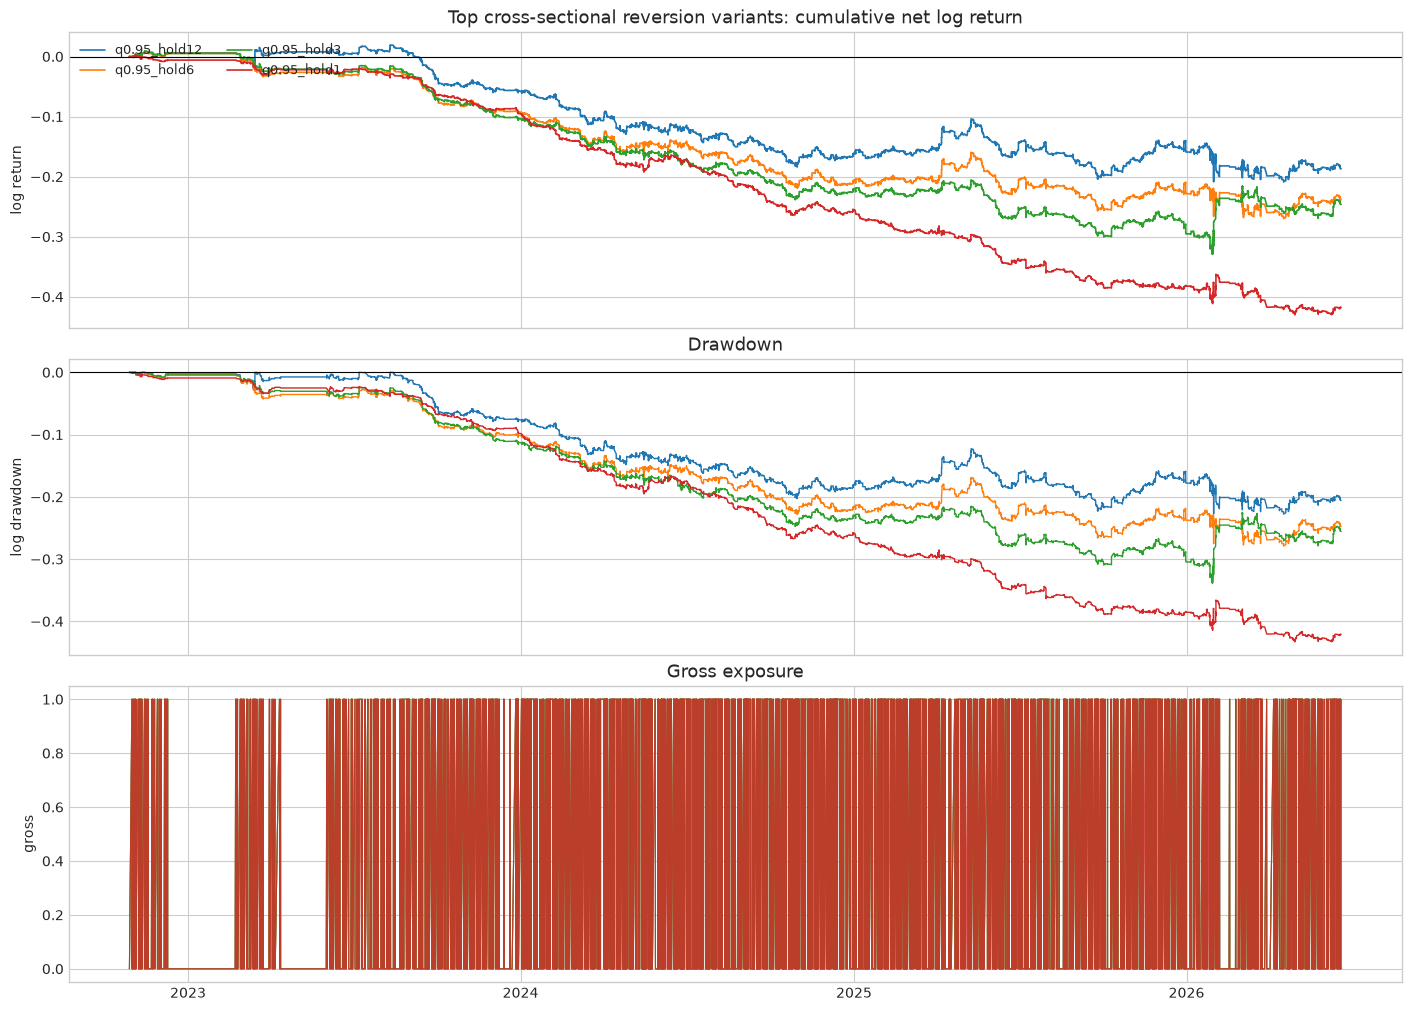

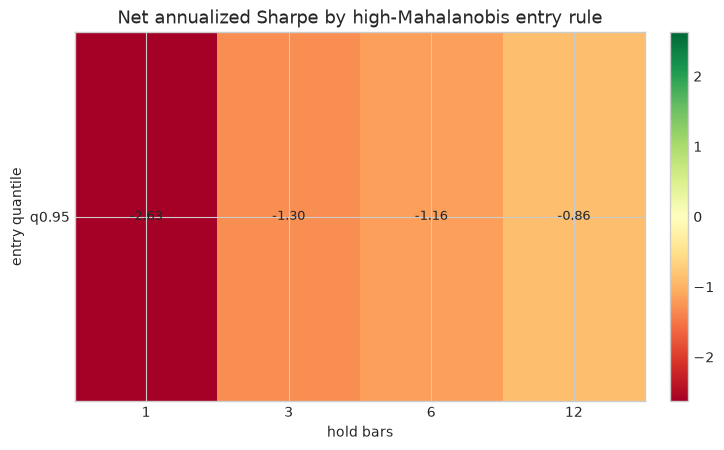

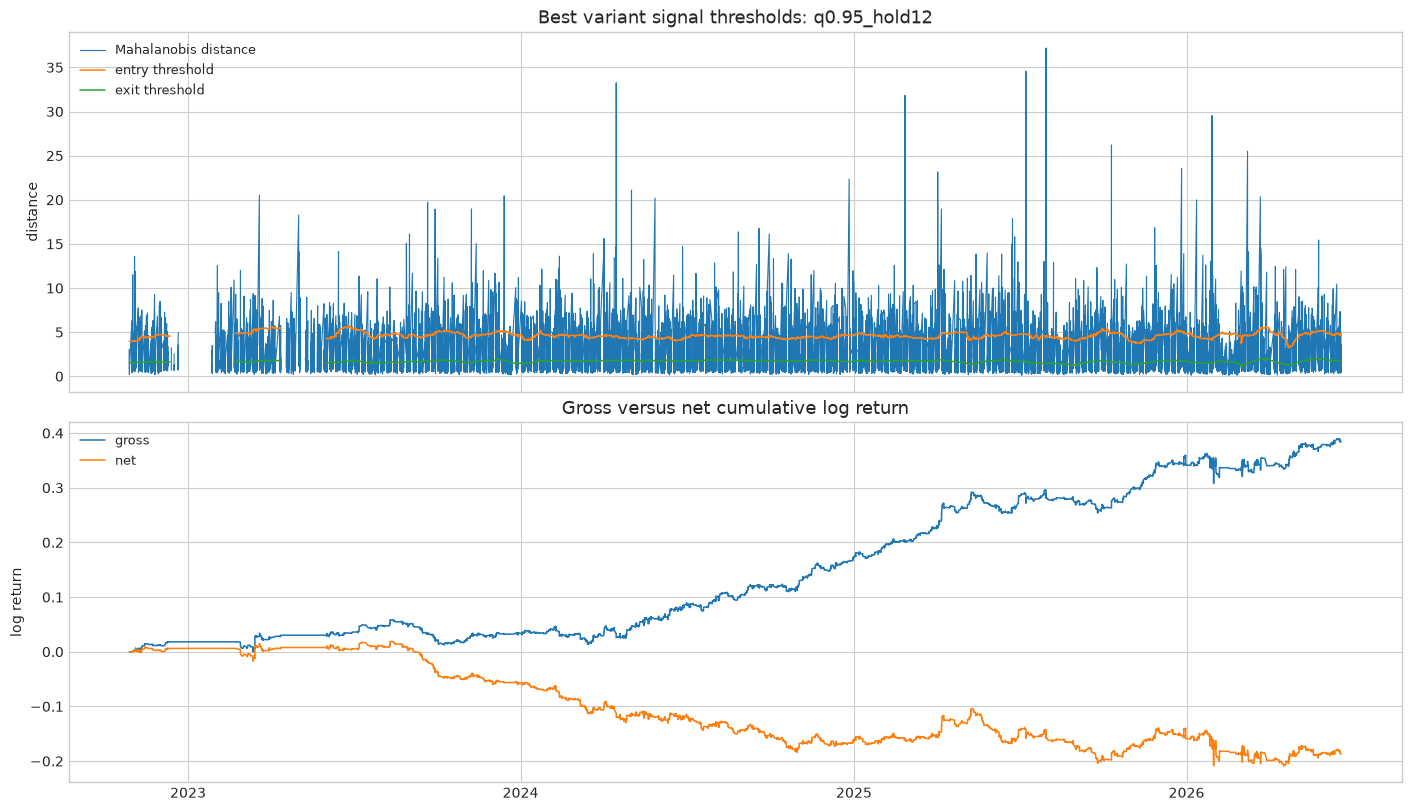

In [9]:
top_variants = cross_section_metrics.head(4).copy()
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
for row in top_variants.itertuples(index=False):
    label = f"q{row.entry_quantile:.2f}_hold{int(row.hold_bars)}"
    group = cross_section_returns.loc[cross_section_returns["variant"] == label].copy()
    group["cum_net"] = group["net_return"].cumsum()
    group["drawdown"] = group["cum_net"] - group["cum_net"].cummax()
    axes[0].plot(group.index, group["cum_net"], label=label, linewidth=1.2)
    axes[1].plot(group.index, group["drawdown"], label=label, linewidth=1.0)
    axes[2].plot(group.index, group["gross_exposure"], label=label, linewidth=0.8, alpha=0.8)

axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Top cross-sectional reversion variants: cumulative net log return")
axes[0].set_ylabel("log return")
axes[0].legend(loc="upper left", ncol=2)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("log drawdown")
axes[2].set_title("Gross exposure")
axes[2].set_ylabel("gross")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

heatmap = cross_section_metrics.pivot(
    index="entry_quantile", columns="hold_bars", values="annualized_sharpe"
).sort_index(ascending=False)
fig, axis = plt.subplots(figsize=(8, 4.8))
limit = float(np.nanmax(np.abs(heatmap.to_numpy(dtype=float))))
image = axis.imshow(
    heatmap,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-limit if limit > 0 else None,
    vmax=limit if limit > 0 else None,
)
axis.set_xticks(range(len(heatmap.columns)))
axis.set_xticklabels([str(col) for col in heatmap.columns])
axis.set_yticks(range(len(heatmap.index)))
axis.set_yticklabels([f"q{idx:.2f}" for idx in heatmap.index])
axis.set_xlabel("hold bars")
axis.set_ylabel("entry quantile")
axis.set_title("Net annualized Sharpe by high-Mahalanobis entry rule")
for row_idx, row_label in enumerate(heatmap.index):
    for col_idx, col_label in enumerate(heatmap.columns):
        value = heatmap.loc[row_label, col_label]
        axis.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=axis, fraction=0.04, pad=0.04)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
axes[0].plot(
    best_returns.index,
    best_returns["mahalanobis_distance"],
    linewidth=0.8,
    label="Mahalanobis distance",
)
axes[0].plot(
    best_returns.index, best_returns["entry_threshold"], linewidth=1.1, label="entry threshold"
)
axes[0].plot(
    best_returns.index, best_returns["exit_threshold"], linewidth=1.1, label="exit threshold"
)
axes[0].set_title(f"Best variant signal thresholds: {best_label}")
axes[0].set_ylabel("distance")
axes[0].legend(loc="upper left")
axes[1].plot(best_returns.index, best_returns["cum_gross"], label="gross", linewidth=1.1)
axes[1].plot(best_returns.index, best_returns["cum_net"], label="net", linewidth=1.1)
axes[1].set_title("Gross versus net cumulative log return")
axes[1].set_ylabel("log return")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

## 6. State-Exit Cross-Sectional Reversion Basket Backtest

A fixed holding period is only a timing proxy. This version treats the entry shock as the state to be repaired. For each high-Mahalanobis entry, it records the basket direction and the expected payoff from a reversal of the entry shock. The position stays open until cumulative normalized returns move far enough in the profitable direction, or until the complex normalizes and the open trade is profitable. A stop is triggered only when the normalized state moves against the entry thesis by the same target amount.


In [10]:
def run_state_exit_reversion(
    *,
    entry_quantile: float,
    target_fraction: float,
    stop_fraction: float = CROSS_SECTION_STOP_FRACTION,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    entry_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(entry_quantile)
        .shift(1)
    )
    neutral_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(CROSS_SECTION_EXIT_QUANTILE)
        .shift(1)
    )

    signal_5m_returns = resampled_return_vectors(
        beta_hedged_returns[ROOTS], freq=MAHALANOBIS_FREQ
    ).reindex(candidate_weights.index)
    signal_forward_returns = signal_5m_returns.shift(-1)
    raw_forward_returns = forward_raw_5m_returns.reindex(candidate_weights.index)

    timestamps = candidate_weights.index[:-1]
    candidate_values = candidate_weights.reindex(timestamps).to_numpy(dtype=float)
    signal_values = signal_5m_returns.reindex(timestamps).to_numpy(dtype=float)
    signal_forward_values = signal_forward_returns.reindex(timestamps).to_numpy(dtype=float)
    raw_forward_values = raw_forward_returns.reindex(timestamps).to_numpy(dtype=float)
    distance_values = signal_distance.reindex(timestamps).to_numpy(dtype=float)
    entry_values = entry_threshold.reindex(timestamps).to_numpy(dtype=float)
    neutral_values = neutral_threshold.reindex(timestamps).to_numpy(dtype=float)

    rows = []
    trades = []
    previous_position = np.zeros(len(ROOTS), dtype=float)
    current_position = np.zeros(len(ROOTS), dtype=float)
    active = False
    entry_id = 0
    entry_time = pd.NaT
    entry_distance = np.nan
    target_progress = np.nan
    stop_progress = np.nan
    progress = 0.0
    trade_gross = 0.0
    trade_cost = 0.0
    trade_net = 0.0
    holding_bars = 0

    for row, timestamp in enumerate(timestamps):
        exit_reason = ""
        if active:
            normalized = (
                np.isfinite(distance_values[row])
                and np.isfinite(neutral_values[row])
                and distance_values[row] <= neutral_values[row]
            )
            target_hit = progress >= target_progress and trade_net > 0.0
            normalized_profitable = normalized and trade_net > 0.0
            stopped = progress <= stop_progress
            if target_hit or normalized_profitable or stopped:
                exit_reason = (
                    "target_profit"
                    if target_hit
                    else "normalized_profit"
                    if normalized_profitable
                    else "adverse_state"
                )
                exit_cost = float(np.abs(current_position).sum()) * (
                    CROSS_SECTION_COST_BPS / 10_000.0
                )
                trades.append(
                    {
                        "entry_id": entry_id,
                        "entry_time": entry_time,
                        "exit_time": timestamp,
                        "exit_reason": exit_reason,
                        "entry_quantile": entry_quantile,
                        "target_fraction": target_fraction,
                        "entry_distance": entry_distance,
                        "target_progress": target_progress,
                        "exit_progress": progress,
                        "gross_log_return": trade_gross,
                        "cost_log_return": trade_cost + exit_cost,
                        "net_log_return": trade_net - exit_cost,
                        "holding_bars": holding_bars,
                    }
                )
                current_position = np.zeros_like(current_position)
                active = False
                progress = 0.0
                trade_gross = 0.0
                trade_cost = 0.0
                trade_net = 0.0
                holding_bars = 0

        entered = False
        if not active and not exit_reason:
            can_enter = (
                np.isfinite(distance_values[row])
                and np.isfinite(entry_values[row])
                and distance_values[row] > entry_values[row]
                and np.isfinite(candidate_values[row]).all()
                and np.isfinite(signal_values[row]).all()
                and np.abs(candidate_values[row]).sum() > 0.0
            )
            if can_enter:
                current_position = candidate_values[row].copy()
                full_reversion_progress = float(-current_position @ signal_values[row])
                if np.isfinite(full_reversion_progress) and full_reversion_progress > 0.0:
                    entry_id += 1
                    active = True
                    entered = True
                    entry_time = timestamp
                    entry_distance = distance_values[row]
                    target_progress = target_fraction * full_reversion_progress
                    stop_progress = -stop_fraction * target_progress
                    progress = 0.0
                    trade_gross = 0.0
                    trade_cost = 0.0
                    trade_net = 0.0
                    holding_bars = 0
                else:
                    current_position = np.zeros_like(current_position)

        turnover = float(np.abs(current_position - previous_position).sum())
        cost_return = turnover * (CROSS_SECTION_COST_BPS / 10_000.0)
        gross_return = 0.0
        progress_return = 0.0
        if np.isfinite(raw_forward_values[row]).all():
            gross_return = float(current_position @ raw_forward_values[row])
        if active and np.isfinite(signal_forward_values[row]).all():
            progress_return = float(current_position @ signal_forward_values[row])
            progress += progress_return
            trade_gross += gross_return
            trade_cost += cost_return
            trade_net += gross_return - cost_return
            holding_bars += 1

        rows.append(
            {
                "ts": timestamp,
                "entry_quantile": entry_quantile,
                "target_fraction": target_fraction,
                "gross_return": gross_return,
                "cost_return": cost_return,
                "net_return": gross_return - cost_return,
                "turnover": turnover,
                "gross_exposure": float(np.abs(current_position).sum()),
                "mahalanobis_distance": distance_values[row],
                "entry_threshold": entry_values[row],
                "neutral_threshold": neutral_values[row],
                "progress": progress if active else np.nan,
                "target_progress": target_progress if active else np.nan,
                "entry_id": entry_id if active else np.nan,
                "entered": entered,
                "exit_reason": exit_reason,
            }
        )
        previous_position = current_position.copy()

    if active:
        trades.append(
            {
                "entry_id": entry_id,
                "entry_time": entry_time,
                "exit_time": timestamps[-1],
                "exit_reason": "open_at_end",
                "entry_quantile": entry_quantile,
                "target_fraction": target_fraction,
                "entry_distance": entry_distance,
                "target_progress": target_progress,
                "exit_progress": progress,
                "gross_log_return": trade_gross,
                "cost_log_return": trade_cost,
                "net_log_return": trade_net,
                "holding_bars": holding_bars,
            }
        )

    returns = pd.DataFrame(rows).set_index("ts")
    returns["variant"] = f"q{entry_quantile:.2f}_target{target_fraction:.2f}"
    trades_frame = pd.DataFrame(trades)
    return returns, trades_frame


def state_exit_metric_block(
    frame: pd.DataFrame, trades: pd.DataFrame
) -> dict[str, float | int | str | pd.Timestamp]:
    valid = frame.dropna(subset=["net_return"])
    if valid.empty:
        return {"observations": 0}

    net = valid["net_return"]
    gross = valid["gross_return"]
    cost = valid["cost_return"]
    turnover = valid["turnover"]
    equity = net.cumsum()
    drawdown = equity - equity.cummax()
    calendar_days = (valid.index[-1] - valid.index[0]).total_seconds() / 86_400.0
    bars_per_year = len(valid) / calendar_days * 365.25 if calendar_days > 0.0 else np.nan
    net_std = net.std(ddof=1)
    sharpe = (
        float(net.mean() / net_std * np.sqrt(bars_per_year))
        if net_std > 0.0 and np.isfinite(bars_per_year)
        else np.nan
    )
    tstat = float(net.mean() / net_std * np.sqrt(len(valid))) if net_std > 0.0 else np.nan
    closed_trades = (
        trades.loc[trades["exit_reason"].ne("open_at_end")].copy() if not trades.empty else trades
    )
    winning_trades = (
        float((closed_trades["net_log_return"] > 0.0).mean()) if len(closed_trades) else np.nan
    )

    return {
        "variant": valid["variant"].iloc[0],
        "entry_quantile": float(valid["entry_quantile"].iloc[0]),
        "target_fraction": float(valid["target_fraction"].iloc[0]),
        "observations": int(len(valid)),
        "start": valid.index[0],
        "end": valid.index[-1],
        "entries": int(valid["entered"].sum()),
        "closed_trades": int(len(closed_trades)),
        "open_at_end": int((trades["exit_reason"].eq("open_at_end")).sum())
        if not trades.empty
        else 0,
        "gross_log_return": float(gross.sum()),
        "cost_log_return": float(cost.sum()),
        "net_log_return": float(net.sum()),
        "compounded_net_return": float(np.expm1(net.sum())),
        "mean_net_bps_per_bar": float(net.mean() * 10_000.0),
        "bar_tstat": tstat,
        "annualized_sharpe": sharpe,
        "max_drawdown_log": float(drawdown.min()),
        "active_fraction": float((valid["gross_exposure"] > 0.0).mean()),
        "avg_turnover": float(turnover.mean()),
        "p95_turnover": float(turnover.quantile(0.95)),
        "avg_holding_bars": float(closed_trades["holding_bars"].mean())
        if len(closed_trades)
        else np.nan,
        "p95_holding_bars": float(closed_trades["holding_bars"].quantile(0.95))
        if len(closed_trades)
        else np.nan,
        "win_rate_trades": winning_trades,
    }


state_exit_frames = []
state_exit_trade_frames = []
state_exit_metric_rows = []
for entry_quantile in CROSS_SECTION_ENTRY_QUANTILES:
    for target_fraction in CROSS_SECTION_REVERSION_TARGETS:
        frame, trades = run_state_exit_reversion(
            entry_quantile=entry_quantile,
            target_fraction=target_fraction,
        )
        state_exit_frames.append(frame)
        state_exit_trade_frames.append(trades)
        state_exit_metric_rows.append(state_exit_metric_block(frame, trades))

state_exit_returns = pd.concat(state_exit_frames).sort_index()
state_exit_trades = pd.concat(state_exit_trade_frames, ignore_index=True)
state_exit_metrics = pd.DataFrame(state_exit_metric_rows).sort_values(
    "annualized_sharpe", ascending=False
)
display(state_exit_metrics)

best_state_exit = state_exit_metrics.iloc[0]
best_state_exit_label = str(best_state_exit["variant"])
best_state_exit_returns = state_exit_returns.loc[
    state_exit_returns["variant"] == best_state_exit_label
].copy()
best_state_exit_trades = state_exit_trades.loc[
    (state_exit_trades["entry_quantile"] == best_state_exit["entry_quantile"])
    & (state_exit_trades["target_fraction"] == best_state_exit["target_fraction"])
].copy()
best_state_exit_returns["cum_net"] = best_state_exit_returns["net_return"].cumsum()
best_state_exit_returns["cum_gross"] = best_state_exit_returns["gross_return"].cumsum()
best_state_exit_returns["drawdown"] = (
    best_state_exit_returns["cum_net"] - best_state_exit_returns["cum_net"].cummax()
)

print(f"Best state-exit variant by net Sharpe: {best_state_exit_label}")
print(
    f"Net log return={best_state_exit.net_log_return:.4f}, "
    f"gross={best_state_exit.gross_log_return:.4f}, "
    f"cost={best_state_exit.cost_log_return:.4f}, "
    f"Sharpe={best_state_exit.annualized_sharpe:.2f}, "
    f"max DD={best_state_exit.max_drawdown_log:.4f}, "
    f"entries={int(best_state_exit.entries)}, "
    f"avg hold={best_state_exit.avg_holding_bars:.1f} bars"
)

,variant,entry_quantile,target_fraction,observations,start,end,entries,closed_trades,open_at_end,gross_log_return,...,mean_net_bps_per_bar,bar_tstat,annualized_sharpe,max_drawdown_log,active_fraction,avg_turnover,p95_turnover,avg_holding_bars,p95_holding_bars,win_rate_trades
2,q0.95_target1.00,0.95,1.00,59588,2020-11-13 16:55:00+00:00,2026-06-19 15:35:00+00:00,1392,1392,0,0.321511,...,-0.016126,-0.626761,-0.264949,-0.258928,0.298785,0.046721,0.0,12.790230,40.0,0.676724
1,q0.95_target0.50,0.95,0.50,59588,2020-11-13 16:55:00+00:00,2026-06-19 15:35:00+00:00,1806,1806,0,0.371875,...,-0.028517,-1.374685,-0.581117,-0.259145,0.172233,0.060616,1.0,5.682724,16.0,0.610188
0,q0.95_target0.25,0.95,0.25,59588,2020-11-13 16:55:00+00:00,2026-06-19 15:35:00+00:00,2064,2064,0,0.344183,...,-0.046153,-2.649086,-1.119842,-0.315608,0.102135,0.069276,1.0,2.948643,8.0,0.547965


Best state-exit variant by net Sharpe: q0.95_target1.00
Net log return=-0.0961, gross=0.3215, cost=0.4176, Sharpe=-0.26, max DD=-0.2589, entries=1392, avg hold=12.8 bars


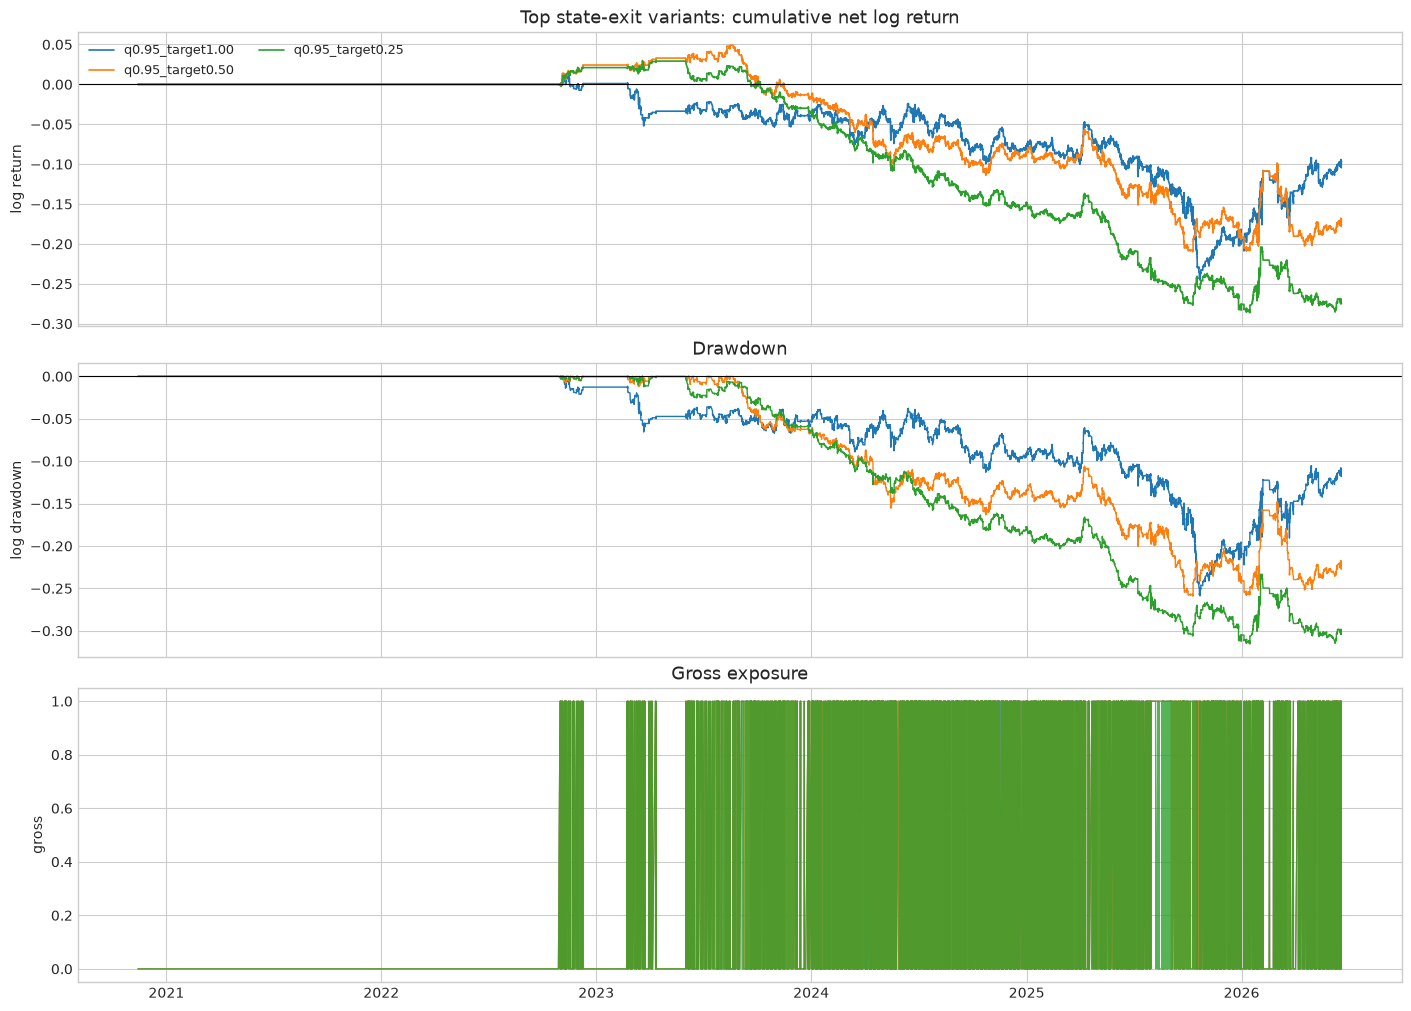

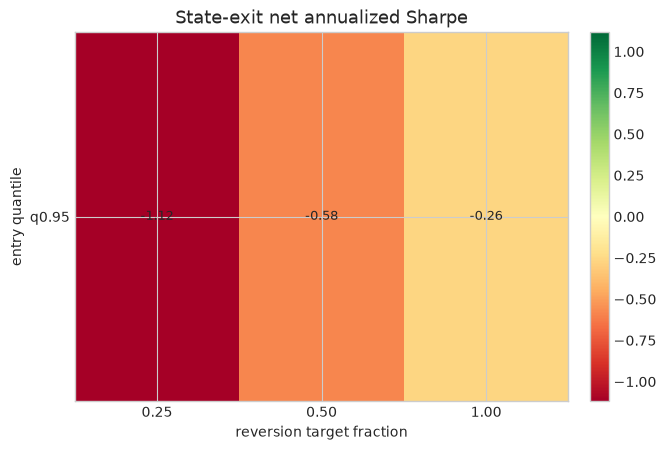

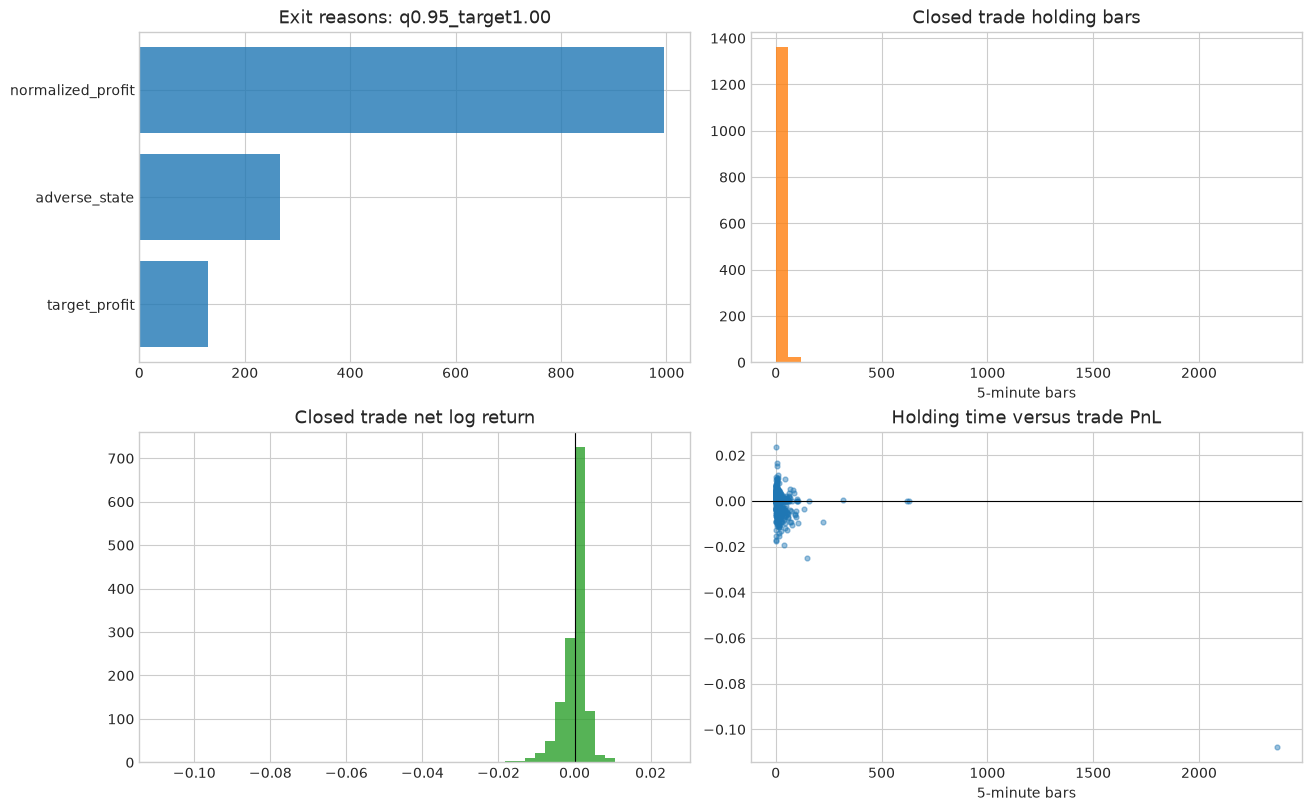

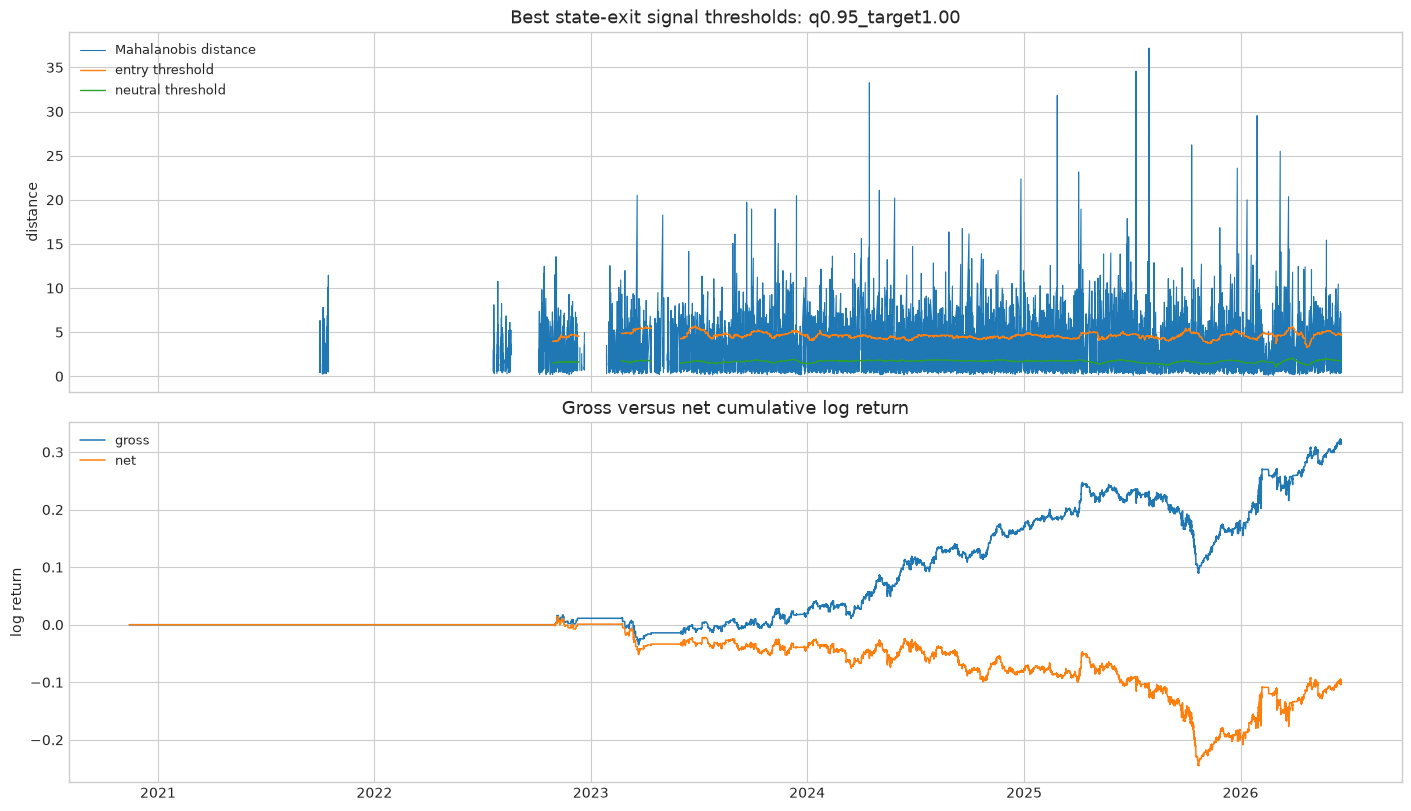

In [11]:
top_state_variants = state_exit_metrics.head(4).copy()
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
for row in top_state_variants.itertuples(index=False):
    label = row.variant
    group = state_exit_returns.loc[state_exit_returns["variant"] == label].copy()
    group["cum_net"] = group["net_return"].cumsum()
    group["drawdown"] = group["cum_net"] - group["cum_net"].cummax()
    axes[0].plot(group.index, group["cum_net"], label=label, linewidth=1.2)
    axes[1].plot(group.index, group["drawdown"], label=label, linewidth=1.0)
    axes[2].plot(group.index, group["gross_exposure"], label=label, linewidth=0.8, alpha=0.8)

axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Top state-exit variants: cumulative net log return")
axes[0].set_ylabel("log return")
axes[0].legend(loc="upper left", ncol=2)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("log drawdown")
axes[2].set_title("Gross exposure")
axes[2].set_ylabel("gross")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

heatmap = state_exit_metrics.pivot(
    index="entry_quantile", columns="target_fraction", values="annualized_sharpe"
).sort_index(ascending=False)
fig, axis = plt.subplots(figsize=(7, 4.8))
limit = float(np.nanmax(np.abs(heatmap.to_numpy(dtype=float))))
image = axis.imshow(
    heatmap,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-limit if limit > 0 else None,
    vmax=limit if limit > 0 else None,
)
axis.set_xticks(range(len(heatmap.columns)))
axis.set_xticklabels([f"{col:.2f}" for col in heatmap.columns])
axis.set_yticks(range(len(heatmap.index)))
axis.set_yticklabels([f"q{idx:.2f}" for idx in heatmap.index])
axis.set_xlabel("reversion target fraction")
axis.set_ylabel("entry quantile")
axis.set_title("State-exit net annualized Sharpe")
for row_idx, row_label in enumerate(heatmap.index):
    for col_idx, col_label in enumerate(heatmap.columns):
        value = heatmap.loc[row_label, col_label]
        axis.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=axis, fraction=0.05, pad=0.04)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
reason_counts = best_state_exit_trades["exit_reason"].value_counts().sort_values(ascending=True)
axes[0, 0].barh(reason_counts.index.astype(str), reason_counts.values, color="tab:blue", alpha=0.8)
axes[0, 0].set_title(f"Exit reasons: {best_state_exit_label}")
closed = best_state_exit_trades.loc[best_state_exit_trades["exit_reason"].ne("open_at_end")].copy()
axes[0, 1].hist(closed["holding_bars"], bins=40, color="tab:orange", alpha=0.8)
axes[0, 1].set_title("Closed trade holding bars")
axes[0, 1].set_xlabel("5-minute bars")
axes[1, 0].hist(closed["net_log_return"], bins=50, color="tab:green", alpha=0.8)
axes[1, 0].axvline(0.0, color="black", linewidth=0.8)
axes[1, 0].set_title("Closed trade net log return")
axes[1, 1].scatter(closed["holding_bars"], closed["net_log_return"], s=12, alpha=0.45)
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_title("Holding time versus trade PnL")
axes[1, 1].set_xlabel("5-minute bars")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
axes[0].plot(
    best_state_exit_returns.index,
    best_state_exit_returns["mahalanobis_distance"],
    linewidth=0.8,
    label="Mahalanobis distance",
)
axes[0].plot(
    best_state_exit_returns.index,
    best_state_exit_returns["entry_threshold"],
    linewidth=1.0,
    label="entry threshold",
)
axes[0].plot(
    best_state_exit_returns.index,
    best_state_exit_returns["neutral_threshold"],
    linewidth=1.0,
    label="neutral threshold",
)
axes[0].set_title(f"Best state-exit signal thresholds: {best_state_exit_label}")
axes[0].set_ylabel("distance")
axes[0].legend(loc="upper left")
axes[1].plot(
    best_state_exit_returns.index,
    best_state_exit_returns["cum_gross"],
    label="gross",
    linewidth=1.1,
)
axes[1].plot(
    best_state_exit_returns.index, best_state_exit_returns["cum_net"], label="net", linewidth=1.1
)
axes[1].set_title("Gross versus net cumulative log return")
axes[1].set_ylabel("log return")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

## 7. Edge-Gated Concentrated Q95 Basket

This is the combined strategy: `q95` Mahalanobis is only a regime filter, and the trade fires only if the projected full reversion payoff is at least `3x` the expected full round-trip cost. The basket is concentrated to the single strongest long contributor and the single strongest short contributor, each using half of gross exposure.


In [12]:
def concentrated_signal_weights(
    score_frame: pd.DataFrame,
    *,
    top_per_side: int = CONCENTRATED_TOP_PER_SIDE,
) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=score_frame.index, columns=score_frame.columns)
    for timestamp, row in score_frame.iterrows():
        scores = row.replace([np.inf, -np.inf], np.nan).dropna()
        if len(scores) < 2 * top_per_side:
            continue
        centered = scores - scores.mean()
        longs = centered.nsmallest(top_per_side).index
        shorts = centered.nlargest(top_per_side).index
        if len(set(longs).intersection(set(shorts))) > 0:
            continue
        weights.loc[timestamp, longs] = 0.5 / len(longs)
        weights.loc[timestamp, shorts] = -0.5 / len(shorts)
    return weights


def run_q95_edge_gated_concentrated_reversion() -> (
    tuple[pd.DataFrame, pd.DataFrame, dict[str, object]]
):
    entry_quantile = 0.95
    target_fraction = CONCENTRATED_TARGET_FRACTION
    entry_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(entry_quantile)
        .shift(1)
    )
    neutral_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(CROSS_SECTION_EXIT_QUANTILE)
        .shift(1)
    )

    concentrated_weights = concentrated_signal_weights(signal_scores)
    signal_5m_returns = resampled_return_vectors(
        beta_hedged_returns[ROOTS], freq=MAHALANOBIS_FREQ
    ).reindex(concentrated_weights.index)
    signal_forward_returns = signal_5m_returns.shift(-1)
    raw_forward_returns = forward_raw_5m_returns.reindex(concentrated_weights.index)

    timestamps = concentrated_weights.index[:-1]
    weight_values = concentrated_weights.reindex(timestamps).to_numpy(dtype=float)
    signal_values = signal_5m_returns.reindex(timestamps).to_numpy(dtype=float)
    signal_forward_values = signal_forward_returns.reindex(timestamps).to_numpy(dtype=float)
    raw_forward_values = raw_forward_returns.reindex(timestamps).to_numpy(dtype=float)
    distance_values = signal_distance.reindex(timestamps).to_numpy(dtype=float)
    entry_values = entry_threshold.reindex(timestamps).to_numpy(dtype=float)
    neutral_values = neutral_threshold.reindex(timestamps).to_numpy(dtype=float)

    expected_round_trip_cost = 2.0 * (CROSS_SECTION_COST_BPS / 10_000.0)
    required_edge = CONCENTRATED_EDGE_COST_MULTIPLE * expected_round_trip_cost

    rows = []
    trades = []
    previous_position = np.zeros(len(ROOTS), dtype=float)
    current_position = np.zeros(len(ROOTS), dtype=float)
    active = False
    entry_id = 0
    entry_time = pd.NaT
    entry_distance = np.nan
    entry_expected_edge = np.nan
    target_progress = np.nan
    stop_progress = np.nan
    progress = 0.0
    trade_gross = 0.0
    trade_cost = 0.0
    trade_net = 0.0
    holding_bars = 0

    for row, timestamp in enumerate(timestamps):
        exit_reason = ""
        if active:
            normalized = (
                np.isfinite(distance_values[row])
                and np.isfinite(neutral_values[row])
                and distance_values[row] <= neutral_values[row]
            )
            target_hit = progress >= target_progress and trade_net > 0.0
            normalized_profitable = normalized and trade_net > 0.0
            stopped = progress <= stop_progress
            if target_hit or normalized_profitable or stopped:
                exit_reason = (
                    "target_profit"
                    if target_hit
                    else "normalized_profit"
                    if normalized_profitable
                    else "adverse_state"
                )
                exit_cost = float(np.abs(current_position).sum()) * (
                    CROSS_SECTION_COST_BPS / 10_000.0
                )
                trades.append(
                    {
                        "entry_id": entry_id,
                        "entry_time": entry_time,
                        "exit_time": timestamp,
                        "exit_reason": exit_reason,
                        "entry_distance": entry_distance,
                        "entry_expected_edge": entry_expected_edge,
                        "required_edge": required_edge,
                        "target_progress": target_progress,
                        "exit_progress": progress,
                        "gross_log_return": trade_gross,
                        "cost_log_return": trade_cost + exit_cost,
                        "net_log_return": trade_net - exit_cost,
                        "holding_bars": holding_bars,
                    }
                )
                current_position = np.zeros_like(current_position)
                active = False
                progress = 0.0
                trade_gross = 0.0
                trade_cost = 0.0
                trade_net = 0.0
                holding_bars = 0

        entered = False
        projected_edge = np.nan
        if not active and not exit_reason:
            if np.isfinite(weight_values[row]).all() and np.isfinite(signal_values[row]).all():
                projected_edge = float(-weight_values[row] @ signal_values[row])
            can_enter = (
                np.isfinite(distance_values[row])
                and np.isfinite(entry_values[row])
                and distance_values[row] > entry_values[row]
                and np.isfinite(projected_edge)
                and projected_edge >= required_edge
                and np.abs(weight_values[row]).sum() > 0.0
            )
            if can_enter:
                current_position = weight_values[row].copy()
                entry_id += 1
                active = True
                entered = True
                entry_time = timestamp
                entry_distance = distance_values[row]
                entry_expected_edge = projected_edge
                target_progress = target_fraction * projected_edge
                stop_progress = -CROSS_SECTION_STOP_FRACTION * target_progress
                progress = 0.0
                trade_gross = 0.0
                trade_cost = 0.0
                trade_net = 0.0
                holding_bars = 0
            else:
                current_position = np.zeros_like(current_position)

        turnover = float(np.abs(current_position - previous_position).sum())
        cost_return = turnover * (CROSS_SECTION_COST_BPS / 10_000.0)
        gross_return = 0.0
        progress_return = 0.0
        if np.isfinite(raw_forward_values[row]).all():
            gross_return = float(current_position @ raw_forward_values[row])
        if active and np.isfinite(signal_forward_values[row]).all():
            progress_return = float(current_position @ signal_forward_values[row])
            progress += progress_return
            trade_gross += gross_return
            trade_cost += cost_return
            trade_net += gross_return - cost_return
            holding_bars += 1

        rows.append(
            {
                "ts": timestamp,
                "gross_return": gross_return,
                "cost_return": cost_return,
                "net_return": gross_return - cost_return,
                "turnover": turnover,
                "gross_exposure": float(np.abs(current_position).sum()),
                "mahalanobis_distance": distance_values[row],
                "entry_threshold": entry_values[row],
                "neutral_threshold": neutral_values[row],
                "projected_edge": projected_edge,
                "required_edge": required_edge,
                "edge_to_cost": projected_edge / expected_round_trip_cost
                if np.isfinite(projected_edge)
                else np.nan,
                "progress": progress if active else np.nan,
                "target_progress": target_progress if active else np.nan,
                "entry_id": entry_id if active else np.nan,
                "entered": entered,
                "exit_reason": exit_reason,
            }
        )
        previous_position = current_position.copy()

    if active:
        trades.append(
            {
                "entry_id": entry_id,
                "entry_time": entry_time,
                "exit_time": timestamps[-1],
                "exit_reason": "open_at_end",
                "entry_distance": entry_distance,
                "entry_expected_edge": entry_expected_edge,
                "required_edge": required_edge,
                "target_progress": target_progress,
                "exit_progress": progress,
                "gross_log_return": trade_gross,
                "cost_log_return": trade_cost,
                "net_log_return": trade_net,
                "holding_bars": holding_bars,
            }
        )

    returns = pd.DataFrame(rows).set_index("ts")
    returns["variant"] = "q95_edge3x_top1x1_state_exit"
    returns["entry_quantile"] = entry_quantile
    returns["target_fraction"] = target_fraction
    trades_frame = pd.DataFrame(trades)
    metrics = state_exit_metric_block(returns, trades_frame)
    metrics.update(
        {
            "variant": "q95_edge3x_top1x1_state_exit",
            "required_edge": required_edge,
            "expected_round_trip_cost": expected_round_trip_cost,
            "edge_cost_multiple_required": CONCENTRATED_EDGE_COST_MULTIPLE,
            "top_per_side": CONCENTRATED_TOP_PER_SIDE,
            "median_entry_expected_edge": float(trades_frame["entry_expected_edge"].median())
            if len(trades_frame)
            else np.nan,
            "median_entry_edge_to_cost": float(
                (trades_frame["entry_expected_edge"] / expected_round_trip_cost).median()
            )
            if len(trades_frame)
            else np.nan,
            "gross_to_cost_ratio": float(metrics["gross_log_return"] / metrics["cost_log_return"])
            if metrics.get("cost_log_return", 0.0)
            else np.nan,
        }
    )
    return returns, trades_frame, metrics


concentrated_returns, concentrated_trades, concentrated_metrics = (
    run_q95_edge_gated_concentrated_reversion()
)
concentrated_metrics_frame = pd.DataFrame([concentrated_metrics])
display(concentrated_metrics_frame.T.rename(columns={0: "q95_edge3x_top1x1_state_exit"}))

concentrated_returns["cum_net"] = concentrated_returns["net_return"].cumsum()
concentrated_returns["cum_gross"] = concentrated_returns["gross_return"].cumsum()
concentrated_returns["drawdown"] = (
    concentrated_returns["cum_net"] - concentrated_returns["cum_net"].cummax()
)

print(
    f"Concentrated q95 edge-gated result: gross={concentrated_metrics['gross_log_return']:.4f}, "
    f"cost={concentrated_metrics['cost_log_return']:.4f}, "
    f"gross/cost={concentrated_metrics['gross_to_cost_ratio']:.2f}x, "
    f"net={concentrated_metrics['net_log_return']:.4f}, "
    f"Sharpe={concentrated_metrics['annualized_sharpe']:.2f}, "
    f"entries={concentrated_metrics['entries']}"
)

,q95_edge3x_top1x1_state_exit
variant,q95_edge3x_top1x1_state_exit
entry_quantile,0.95
target_fraction,1.0
observations,59588
start,2020-11-13 16:55:00+00:00
end,2026-06-19 15:35:00+00:00
entries,1534
closed_trades,1533
open_at_end,1
gross_log_return,0.405361


Concentrated q95 edge-gated result: gross=0.4054, cost=0.4601, gross/cost=0.88x, net=-0.0547, Sharpe=-0.12, entries=1534


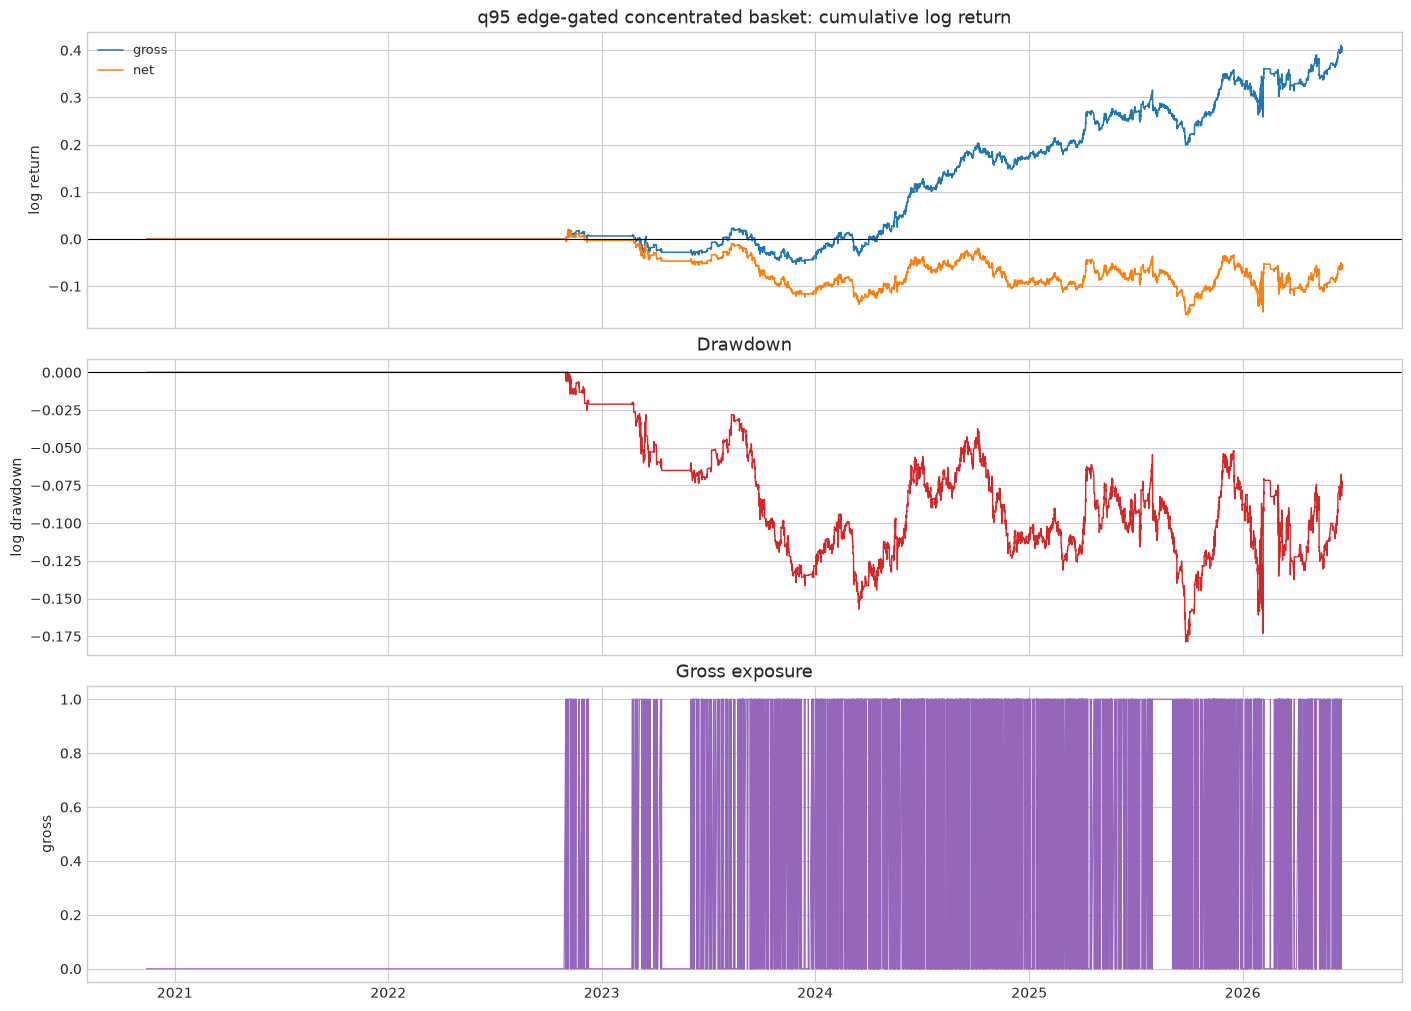

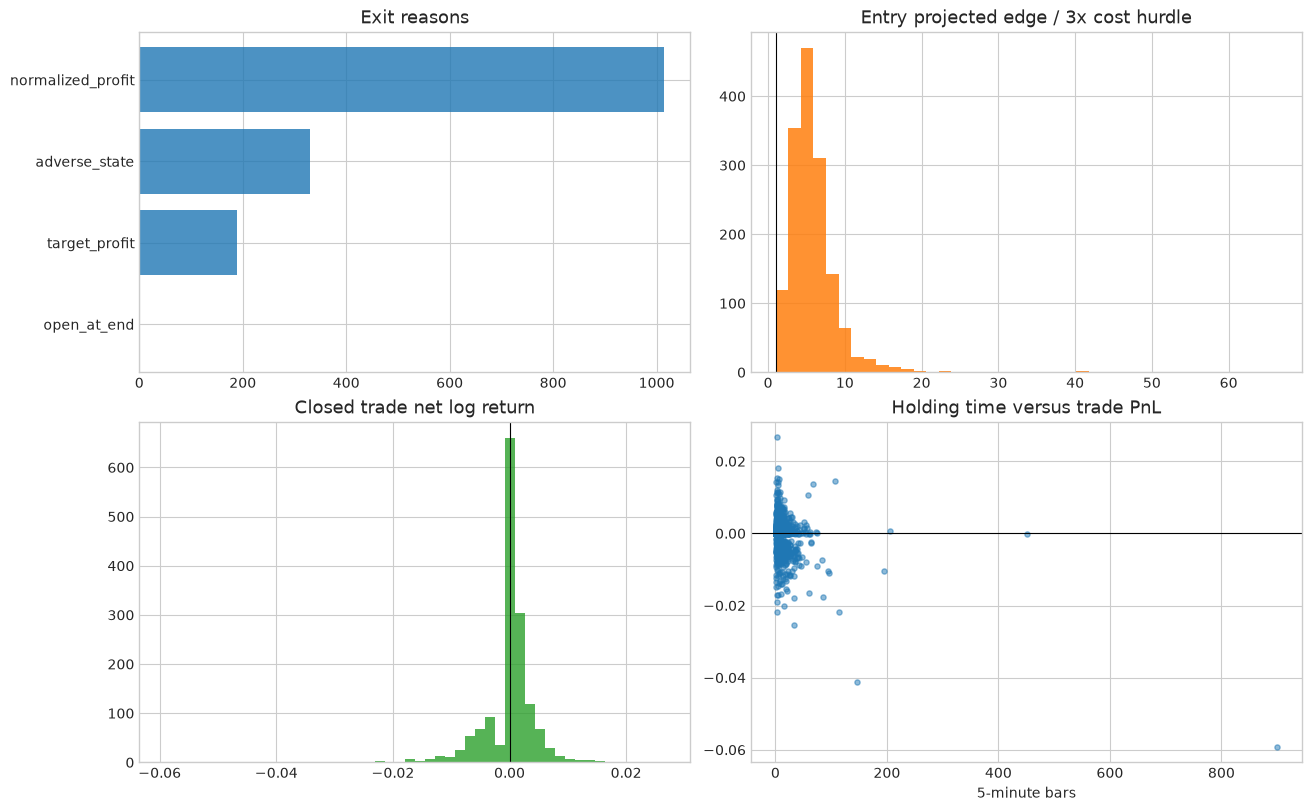

,0,1
variant,q0.95_target1.00,q95_edge3x_top1x1_state_exit
entries,1392,1534
gross_log_return,0.321511,0.405361
cost_log_return,0.4176,0.46005
gross_to_cost_ratio,NaN,0.881124
net_log_return,-0.096089,-0.054689
annualized_sharpe,-0.264949,-0.123692
max_drawdown_log,-0.258928,-0.17874
win_rate_trades,0.676724,0.684932
avg_holding_bars,12.79023,9.465101


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
axes[0].plot(
    concentrated_returns.index, concentrated_returns["cum_gross"], label="gross", linewidth=1.1
)
axes[0].plot(
    concentrated_returns.index, concentrated_returns["cum_net"], label="net", linewidth=1.1
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("q95 edge-gated concentrated basket: cumulative log return")
axes[0].set_ylabel("log return")
axes[0].legend(loc="upper left")
axes[1].plot(
    concentrated_returns.index, concentrated_returns["drawdown"], color="tab:red", linewidth=1.0
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("log drawdown")
axes[2].plot(
    concentrated_returns.index,
    concentrated_returns["gross_exposure"],
    color="tab:purple",
    linewidth=0.8,
)
axes[2].set_title("Gross exposure")
axes[2].set_ylabel("gross")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
closed = concentrated_trades.loc[concentrated_trades["exit_reason"].ne("open_at_end")].copy()
reason_counts = concentrated_trades["exit_reason"].value_counts().sort_values(ascending=True)
axes[0, 0].barh(reason_counts.index.astype(str), reason_counts.values, color="tab:blue", alpha=0.8)
axes[0, 0].set_title("Exit reasons")
axes[0, 1].hist(
    closed["entry_expected_edge"] / closed["required_edge"], bins=40, color="tab:orange", alpha=0.85
)
axes[0, 1].axvline(1.0, color="black", linewidth=0.8)
axes[0, 1].set_title("Entry projected edge / 3x cost hurdle")
axes[1, 0].hist(closed["net_log_return"], bins=50, color="tab:green", alpha=0.8)
axes[1, 0].axvline(0.0, color="black", linewidth=0.8)
axes[1, 0].set_title("Closed trade net log return")
axes[1, 1].scatter(closed["holding_bars"], closed["net_log_return"], s=14, alpha=0.5)
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_title("Holding time versus trade PnL")
axes[1, 1].set_xlabel("5-minute bars")
plt.show()

comparison_rows = []
if "state_exit_metrics" in globals():
    comparison_rows.append(state_exit_metrics.iloc[0].to_dict())
comparison_rows.append(concentrated_metrics)
comparison = pd.DataFrame(comparison_rows)
display(
    comparison[
        [
            "variant",
            "entries",
            "gross_log_return",
            "cost_log_return",
            "gross_to_cost_ratio"
            if "gross_to_cost_ratio" in comparison.columns
            else "net_log_return",
            "net_log_return",
            "annualized_sharpe",
            "max_drawdown_log",
            "win_rate_trades",
            "avg_holding_bars",
        ]
    ].T
)

## 8. Empirical-Forecast Concentrated Q95 Basket

The previous gate used mechanical full-reversion potential as if it were a forecast. This version estimates expected gross edge from prior q95 concentrated-basket candidates. Each candidate is conditioned on its long/short contributor pair and projected-edge bucket when enough prior samples exist; otherwise it falls back to the same edge bucket across pairs, then to all prior q95 candidates. The trade is allowed only when the causal empirical expected gross edge is at least `3x` the expected round-trip cost.


In [14]:
def future_return_sum(frame: pd.DataFrame, horizon: int) -> pd.DataFrame:
    values = frame.to_numpy(dtype=float)
    future = np.full_like(values, np.nan, dtype=float)
    cumulative = np.vstack([np.zeros((1, values.shape[1])), np.cumsum(values, axis=0)])
    for row in range(len(values) - horizon):
        future[row] = cumulative[row + horizon + 1] - cumulative[row + 1]
    return pd.DataFrame(future, index=frame.index, columns=frame.columns)


def build_empirical_candidate_frame() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    entry_quantile = 0.95
    entry_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(entry_quantile)
        .shift(1)
    )
    concentrated_weights = concentrated_signal_weights(signal_scores)
    signal_5m_returns = resampled_return_vectors(
        beta_hedged_returns[ROOTS], freq=MAHALANOBIS_FREQ
    ).reindex(concentrated_weights.index)
    raw_5m_returns = resampled_return_vectors(returns[ROOTS], freq=MAHALANOBIS_FREQ).reindex(
        concentrated_weights.index
    )
    future_raw = future_return_sum(raw_5m_returns, EMPIRICAL_FORECAST_BARS)

    projected_edge = -(concentrated_weights * signal_5m_returns).sum(axis=1)
    expected_round_trip_cost = 2.0 * (CROSS_SECTION_COST_BPS / 10_000.0)
    edge_to_cost = projected_edge / expected_round_trip_cost
    edge_bucket = pd.cut(
        edge_to_cost,
        bins=EMPIRICAL_EDGE_BUCKETS,
        labels=[
            f"{EMPIRICAL_EDGE_BUCKETS[i]:g}-{EMPIRICAL_EDGE_BUCKETS[i + 1]:g}"
            for i in range(len(EMPIRICAL_EDGE_BUCKETS) - 2)
        ]
        + [f">={EMPIRICAL_EDGE_BUCKETS[-2]:g}"],
        include_lowest=True,
        right=False,
    ).astype("object")

    long_root = concentrated_weights.idxmax(axis=1)
    short_root = concentrated_weights.idxmin(axis=1)
    has_position = concentrated_weights.abs().sum(axis=1) > 0.0
    long_root = long_root.where(has_position)
    short_root = short_root.where(has_position)
    pair_id = long_root.astype("string") + "_long_vs_" + short_root.astype("string") + "_short"

    forward_gross = (concentrated_weights * future_raw).sum(axis=1)
    candidates = pd.DataFrame(
        {
            "mahalanobis_distance": signal_distance,
            "entry_threshold": entry_threshold,
            "projected_edge": projected_edge,
            "edge_to_cost": edge_to_cost,
            "edge_bucket": edge_bucket,
            "long_root": long_root,
            "short_root": short_root,
            "pair_id": pair_id,
            "forward_gross_12b": forward_gross,
        }
    )
    candidates["is_q95_candidate"] = (
        candidates["mahalanobis_distance"].gt(candidates["entry_threshold"])
        & candidates["projected_edge"].gt(0.0)
        & candidates["edge_bucket"].notna()
        & candidates["pair_id"].notna()
        & candidates["forward_gross_12b"].notna()
    )
    return candidates, concentrated_weights, signal_5m_returns


def add_empirical_forecast(candidates: pd.DataFrame) -> pd.DataFrame:
    candidate_events = candidates.loc[candidates["is_q95_candidate"]].copy()
    candidate_events["empirical_expected_gross"] = np.nan
    candidate_events["empirical_sample_size"] = 0
    candidate_events["empirical_scope"] = "none"
    lookback = pd.Timedelta(days=EMPIRICAL_LOOKBACK_DAYS)

    for row_number, (timestamp, row) in enumerate(candidate_events.iterrows()):
        history = candidate_events.iloc[:row_number]
        if history.empty:
            continue
        history = history.loc[history.index >= timestamp - lookback]
        history = history.dropna(subset=["forward_gross_12b"])
        if history.empty:
            continue

        pair_bucket = history.loc[
            history["pair_id"].eq(row["pair_id"]) & history["edge_bucket"].eq(row["edge_bucket"]),
            "forward_gross_12b",
        ]
        if len(pair_bucket) >= EMPIRICAL_MIN_PAIR_BUCKET:
            sample = pair_bucket
            scope = "pair_bucket"
        else:
            bucket = history.loc[history["edge_bucket"].eq(row["edge_bucket"]), "forward_gross_12b"]
            if len(bucket) >= EMPIRICAL_MIN_BUCKET:
                sample = bucket
                scope = "bucket"
            elif len(history) >= EMPIRICAL_MIN_GLOBAL:
                sample = history["forward_gross_12b"]
                scope = "global"
            else:
                continue

        candidate_events.loc[timestamp, "empirical_expected_gross"] = float(sample.mean())
        candidate_events.loc[timestamp, "empirical_sample_size"] = int(len(sample))
        candidate_events.loc[timestamp, "empirical_scope"] = scope

    enriched = candidates.join(
        candidate_events[["empirical_expected_gross", "empirical_sample_size", "empirical_scope"]],
        how="left",
    )
    enriched["empirical_sample_size"] = enriched["empirical_sample_size"].fillna(0).astype(int)
    enriched["empirical_scope"] = enriched["empirical_scope"].fillna("none")
    return enriched


empirical_candidates, empirical_weights, empirical_signal_returns = (
    build_empirical_candidate_frame()
)
empirical_candidates = add_empirical_forecast(empirical_candidates)

expected_round_trip_cost = 2.0 * (CROSS_SECTION_COST_BPS / 10_000.0)
required_empirical_edge = CONCENTRATED_EDGE_COST_MULTIPLE * expected_round_trip_cost
empirical_candidates["passes_empirical_gate"] = empirical_candidates[
    "is_q95_candidate"
] & empirical_candidates["empirical_expected_gross"].ge(required_empirical_edge)

empirical_gate_summary = pd.Series(
    {
        "q95_candidates": int(empirical_candidates["is_q95_candidate"].sum()),
        "candidates_with_forecast": int(
            (
                empirical_candidates["is_q95_candidate"]
                & empirical_candidates["empirical_expected_gross"].notna()
            ).sum()
        ),
        "passes_empirical_gate": int(empirical_candidates["passes_empirical_gate"].sum()),
        "required_empirical_edge": required_empirical_edge,
        "median_empirical_expected_gross": float(
            empirical_candidates.loc[
                empirical_candidates["passes_empirical_gate"], "empirical_expected_gross"
            ].median()
        ),
        "median_empirical_sample_size": float(
            empirical_candidates.loc[
                empirical_candidates["passes_empirical_gate"], "empirical_sample_size"
            ].median()
        ),
    }
)
display(empirical_gate_summary.to_frame("value"))
display(
    empirical_candidates.loc[empirical_candidates["is_q95_candidate"]]
    .groupby(["edge_bucket", "empirical_scope"], dropna=False)
    .agg(
        candidates=("forward_gross_12b", "size"),
        avg_forward_gross_12b=("forward_gross_12b", "mean"),
        avg_empirical_expected_gross=("empirical_expected_gross", "mean"),
        pass_rate=("passes_empirical_gate", "mean"),
    )
    .sort_index()
)

,value
q95_candidates,2696.000000
candidates_with_forecast,2602.000000
passes_empirical_gate,212.000000
required_empirical_edge,0.000900
median_empirical_expected_gross,0.001374
median_empirical_sample_size,34.000000


candidates  avg_forward_gross_12b  \
edge_bucket empirical_scope                                      
0-3         global                    6               0.001500   
            none                      1              -0.003629   
10-20       bucket                  539               0.000319   
            none                     50              -0.000103   
            pair_bucket             928               0.000129   
3-5         global                   33              -0.000771   
            none                      2               0.003472   
5-10        bucket                  160               0.000908   
            global                   28               0.000072   
            none                     22               0.001530   
            pair_bucket             209               0.000635   
>=20        bucket                  546               0.000598   
            global                   31               0.000236   
            none                     19              -0.000452   
            pair_bucket             122               0.000785   

                             avg_empirical_expected_gross  pass_rate  
edge_bucket empirical_scope                                           
0-3         global                               0.000382   0.000000  
            none                                      NaN   0.000000  
10-20       bucket                               0.000140   0.000000  
            none                                      NaN   0.000000  
            pair_bucket                          0.000139   0.114224  
3-5         global                               0.000366   0.000000  
            none                                      NaN   0.000000  
5-10        bucket                               0.000577   0.112500  
            global                               0.000306   0.000000  
            none                                      NaN   0.000000  
            pair_bucket                          0.000591   0.129187  
>=20        bucket                               0.000279   0.000000  
            global                               0.000277   0.000000  
            none                                      NaN   0.000000  
            pair_bucket                          0.001016   0.500000

In [15]:
def run_empirical_forecast_concentrated_reversion() -> (
    tuple[pd.DataFrame, pd.DataFrame, dict[str, object]]
):
    entry_quantile = 0.95
    target_fraction = CONCENTRATED_TARGET_FRACTION
    neutral_threshold = (
        signal_distance.rolling(f"{MAHALANOBIS_WINDOW_DAYS}D", min_periods=MAHALANOBIS_MIN_OBS)
        .quantile(CROSS_SECTION_EXIT_QUANTILE)
        .shift(1)
    )

    raw_forward_returns = forward_raw_5m_returns.reindex(empirical_weights.index)
    signal_forward_returns = empirical_signal_returns.shift(-1)

    timestamps = empirical_weights.index[:-1]
    weight_values = empirical_weights.reindex(timestamps).to_numpy(dtype=float)
    signal_values = empirical_signal_returns.reindex(timestamps).to_numpy(dtype=float)
    signal_forward_values = signal_forward_returns.reindex(timestamps).to_numpy(dtype=float)
    raw_forward_values = raw_forward_returns.reindex(timestamps).to_numpy(dtype=float)
    distance_values = signal_distance.reindex(timestamps).to_numpy(dtype=float)
    neutral_values = neutral_threshold.reindex(timestamps).to_numpy(dtype=float)
    candidate_values = empirical_candidates.reindex(timestamps)

    expected_round_trip_cost = 2.0 * (CROSS_SECTION_COST_BPS / 10_000.0)
    required_edge = CONCENTRATED_EDGE_COST_MULTIPLE * expected_round_trip_cost

    rows = []
    trades = []
    previous_position = np.zeros(len(ROOTS), dtype=float)
    current_position = np.zeros(len(ROOTS), dtype=float)
    active = False
    entry_id = 0
    entry_time = pd.NaT
    entry_distance = np.nan
    entry_projected_edge = np.nan
    entry_empirical_edge = np.nan
    entry_empirical_scope = "none"
    entry_empirical_sample_size = 0
    target_progress = np.nan
    stop_progress = np.nan
    gross_profit_target = np.nan
    progress = 0.0
    trade_gross = 0.0
    trade_cost = 0.0
    trade_net = 0.0
    holding_bars = 0

    for row, timestamp in enumerate(timestamps):
        exit_reason = ""
        if active:
            normalized = (
                np.isfinite(distance_values[row])
                and np.isfinite(neutral_values[row])
                and distance_values[row] <= neutral_values[row]
            )
            state_target_hit = progress >= target_progress and trade_net > 0.0
            empirical_profit_hit = trade_gross >= gross_profit_target and trade_net > 0.0
            normalized_profitable = normalized and trade_net > 0.0
            stopped = progress <= stop_progress
            if empirical_profit_hit or state_target_hit or normalized_profitable or stopped:
                exit_reason = (
                    "empirical_profit_target"
                    if empirical_profit_hit
                    else "state_target_profit"
                    if state_target_hit
                    else "normalized_profit"
                    if normalized_profitable
                    else "adverse_state"
                )
                exit_cost = float(np.abs(current_position).sum()) * (
                    CROSS_SECTION_COST_BPS / 10_000.0
                )
                trades.append(
                    {
                        "entry_id": entry_id,
                        "entry_time": entry_time,
                        "exit_time": timestamp,
                        "exit_reason": exit_reason,
                        "entry_distance": entry_distance,
                        "entry_projected_edge": entry_projected_edge,
                        "entry_empirical_edge": entry_empirical_edge,
                        "entry_empirical_scope": entry_empirical_scope,
                        "entry_empirical_sample_size": entry_empirical_sample_size,
                        "required_edge": required_edge,
                        "target_progress": target_progress,
                        "exit_progress": progress,
                        "gross_log_return": trade_gross,
                        "cost_log_return": trade_cost + exit_cost,
                        "net_log_return": trade_net - exit_cost,
                        "holding_bars": holding_bars,
                    }
                )
                current_position = np.zeros_like(current_position)
                active = False
                progress = 0.0
                trade_gross = 0.0
                trade_cost = 0.0
                trade_net = 0.0
                holding_bars = 0

        entered = False
        row_candidate = candidate_values.iloc[row]
        empirical_edge = row_candidate.get("empirical_expected_gross", np.nan)
        projected_edge = row_candidate.get("projected_edge", np.nan)
        if not active and not exit_reason:
            can_enter = bool(
                row_candidate.get("passes_empirical_gate", False)
                and np.isfinite(empirical_edge)
                and empirical_edge >= required_edge
                and np.isfinite(projected_edge)
                and projected_edge > 0.0
                and np.isfinite(weight_values[row]).all()
                and np.isfinite(signal_values[row]).all()
                and np.abs(weight_values[row]).sum() > 0.0
            )
            if can_enter:
                current_position = weight_values[row].copy()
                entry_id += 1
                active = True
                entered = True
                entry_time = timestamp
                entry_distance = distance_values[row]
                entry_projected_edge = float(projected_edge)
                entry_empirical_edge = float(empirical_edge)
                entry_empirical_scope = str(row_candidate.get("empirical_scope", "none"))
                entry_empirical_sample_size = int(row_candidate.get("empirical_sample_size", 0))
                target_progress = target_fraction * entry_projected_edge
                stop_progress = -CROSS_SECTION_STOP_FRACTION * target_progress
                gross_profit_target = entry_empirical_edge
                progress = 0.0
                trade_gross = 0.0
                trade_cost = 0.0
                trade_net = 0.0
                holding_bars = 0
            else:
                current_position = np.zeros_like(current_position)

        turnover = float(np.abs(current_position - previous_position).sum())
        cost_return = turnover * (CROSS_SECTION_COST_BPS / 10_000.0)
        gross_return = 0.0
        progress_return = 0.0
        if np.isfinite(raw_forward_values[row]).all():
            gross_return = float(current_position @ raw_forward_values[row])
        if active and np.isfinite(signal_forward_values[row]).all():
            progress_return = float(current_position @ signal_forward_values[row])
            progress += progress_return
            trade_gross += gross_return
            trade_cost += cost_return
            trade_net += gross_return - cost_return
            holding_bars += 1

        rows.append(
            {
                "ts": timestamp,
                "gross_return": gross_return,
                "cost_return": cost_return,
                "net_return": gross_return - cost_return,
                "turnover": turnover,
                "gross_exposure": float(np.abs(current_position).sum()),
                "mahalanobis_distance": distance_values[row],
                "empirical_expected_gross": empirical_edge,
                "required_edge": required_edge,
                "empirical_sample_size": row_candidate.get("empirical_sample_size", 0),
                "entry_quantile": entry_quantile,
                "target_fraction": target_fraction,
                "progress": progress if active else np.nan,
                "target_progress": target_progress if active else np.nan,
                "entry_id": entry_id if active else np.nan,
                "entered": entered,
                "exit_reason": exit_reason,
            }
        )
        previous_position = current_position.copy()

    if active:
        trades.append(
            {
                "entry_id": entry_id,
                "entry_time": entry_time,
                "exit_time": timestamps[-1],
                "exit_reason": "open_at_end",
                "entry_distance": entry_distance,
                "entry_projected_edge": entry_projected_edge,
                "entry_empirical_edge": entry_empirical_edge,
                "entry_empirical_scope": entry_empirical_scope,
                "entry_empirical_sample_size": entry_empirical_sample_size,
                "required_edge": required_edge,
                "target_progress": target_progress,
                "exit_progress": progress,
                "gross_log_return": trade_gross,
                "cost_log_return": trade_cost,
                "net_log_return": trade_net,
                "holding_bars": holding_bars,
            }
        )

    returns = pd.DataFrame(rows).set_index("ts")
    returns["variant"] = "q95_empirical_edge3x_top1x1_state_exit"
    trades_frame = pd.DataFrame(trades)
    metrics = state_exit_metric_block(returns, trades_frame)
    metrics.update(
        {
            "variant": "q95_empirical_edge3x_top1x1_state_exit",
            "required_edge": required_edge,
            "expected_round_trip_cost": expected_round_trip_cost,
            "edge_cost_multiple_required": CONCENTRATED_EDGE_COST_MULTIPLE,
            "top_per_side": CONCENTRATED_TOP_PER_SIDE,
            "median_entry_empirical_edge": float(trades_frame["entry_empirical_edge"].median())
            if len(trades_frame)
            else np.nan,
            "median_entry_projected_edge": float(trades_frame["entry_projected_edge"].median())
            if len(trades_frame)
            else np.nan,
            "median_entry_empirical_sample_size": float(
                trades_frame["entry_empirical_sample_size"].median()
            )
            if len(trades_frame)
            else np.nan,
            "gross_to_cost_ratio": float(metrics["gross_log_return"] / metrics["cost_log_return"])
            if metrics.get("cost_log_return", 0.0)
            else np.nan,
        }
    )
    return returns, trades_frame, metrics


empirical_forecast_returns, empirical_forecast_trades, empirical_forecast_metrics = (
    run_empirical_forecast_concentrated_reversion()
)
empirical_forecast_metrics_frame = pd.DataFrame([empirical_forecast_metrics])
display(
    empirical_forecast_metrics_frame.T.rename(columns={0: "q95_empirical_edge3x_top1x1_state_exit"})
)

empirical_forecast_returns["cum_net"] = empirical_forecast_returns["net_return"].cumsum()
empirical_forecast_returns["cum_gross"] = empirical_forecast_returns["gross_return"].cumsum()
empirical_forecast_returns["drawdown"] = (
    empirical_forecast_returns["cum_net"] - empirical_forecast_returns["cum_net"].cummax()
)

print(
    f"Empirical q95 edge-gated result: gross={empirical_forecast_metrics['gross_log_return']:.4f}, "
    f"cost={empirical_forecast_metrics['cost_log_return']:.4f}, "
    f"gross/cost={empirical_forecast_metrics['gross_to_cost_ratio']:.2f}x, "
    f"net={empirical_forecast_metrics['net_log_return']:.4f}, "
    f"Sharpe={empirical_forecast_metrics['annualized_sharpe']:.2f}, "
    f"entries={empirical_forecast_metrics['entries']}"
)

,q95_empirical_edge3x_top1x1_state_exit
variant,q95_empirical_edge3x_top1x1_state_exit
entry_quantile,0.95
target_fraction,1.0
observations,59588
start,2020-11-13 16:55:00+00:00
end,2026-06-19 15:35:00+00:00
entries,189
closed_trades,189
open_at_end,0
gross_log_return,0.126784


Empirical q95 edge-gated result: gross=0.1268, cost=0.0567, gross/cost=2.24x, net=0.0701, Sharpe=0.39, entries=189


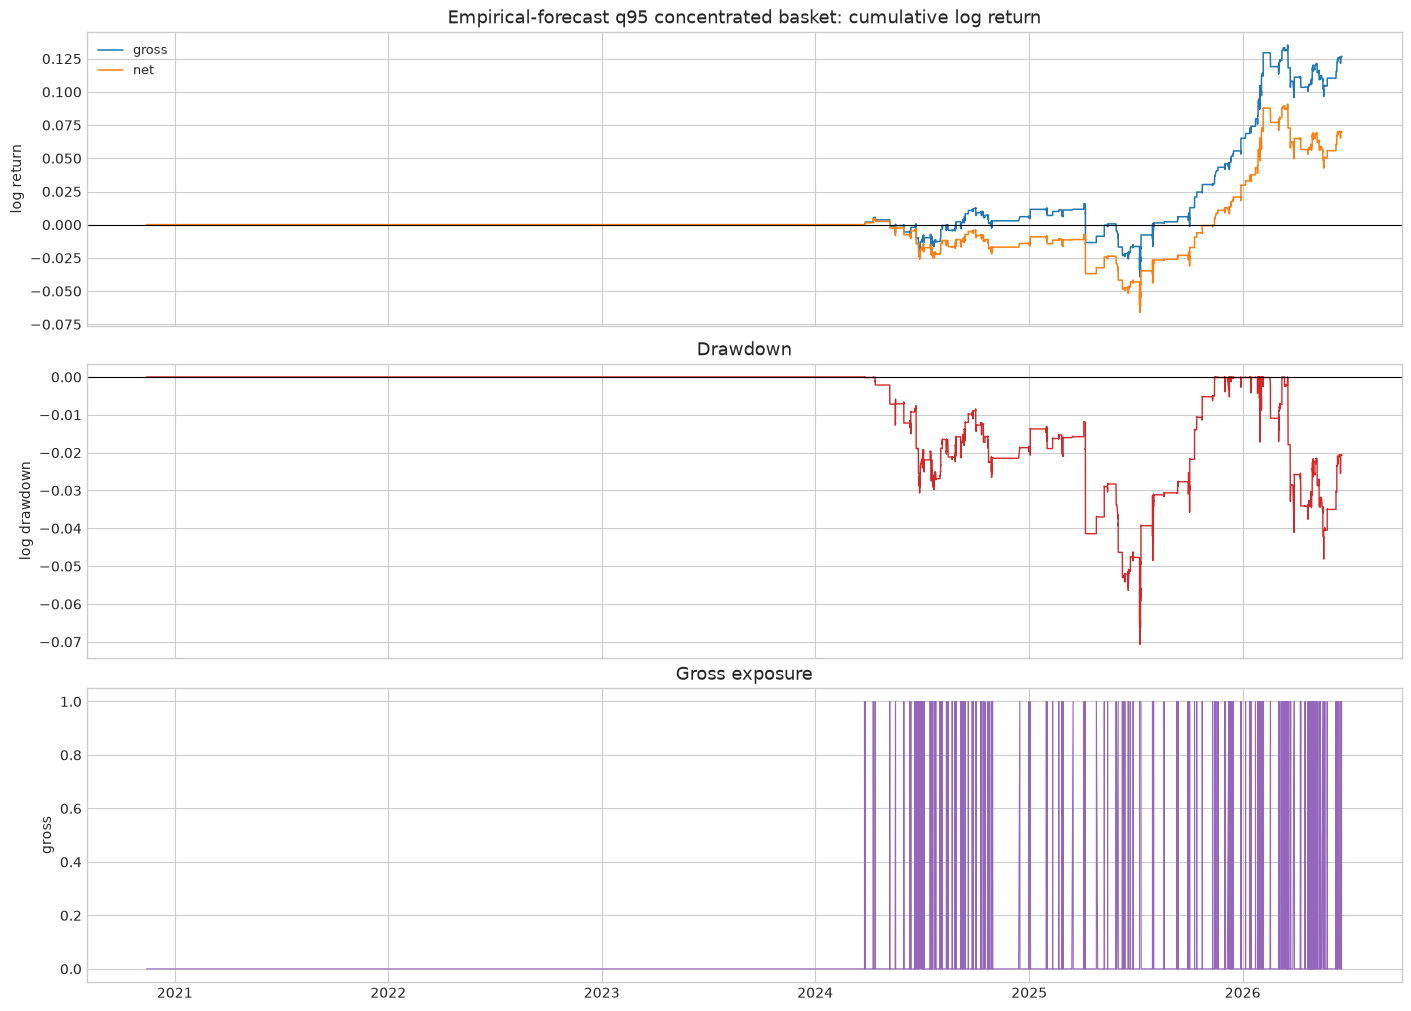

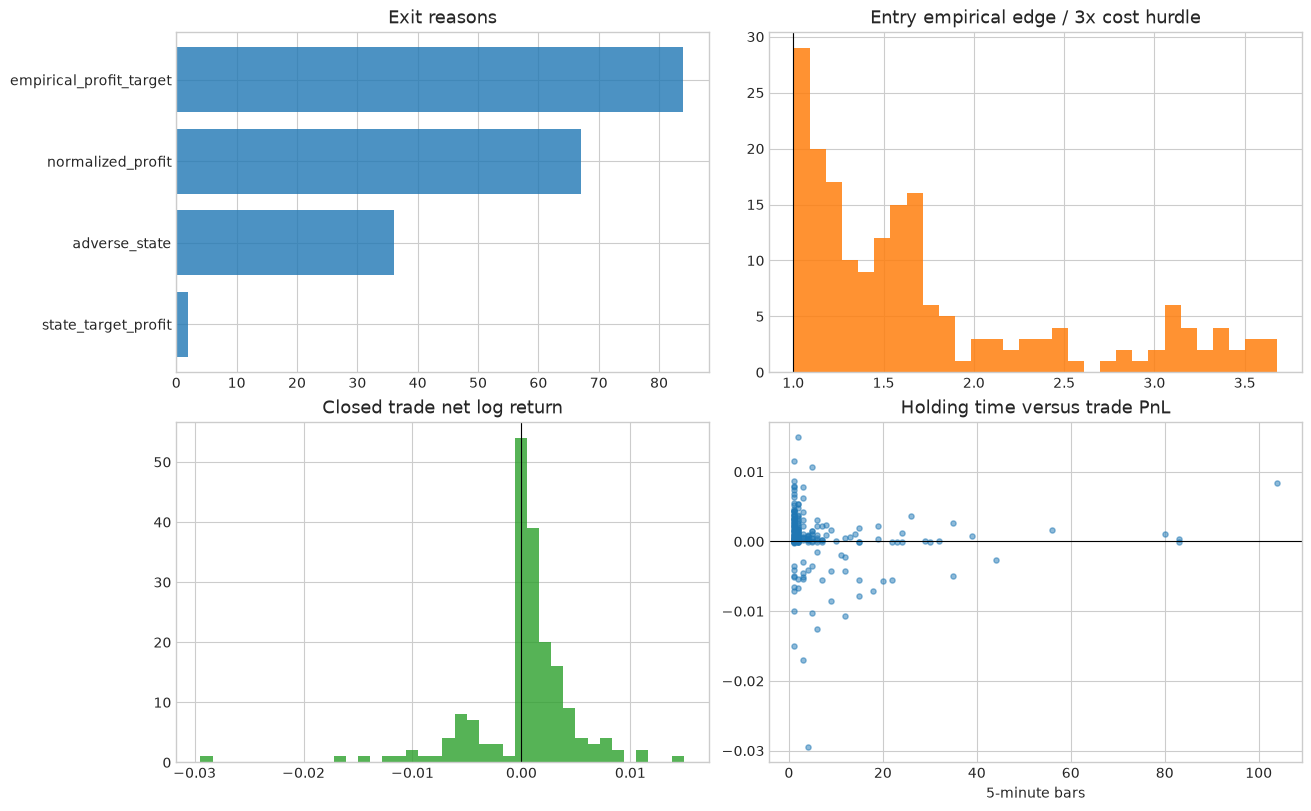

,0,1,2
variant,q0.95_target1.00,q95_edge3x_top1x1_state_exit,q95_empirical_edge3x_top1x1_state_exit
entries,1392,1534,189
gross_log_return,0.321511,0.405361,0.126784
cost_log_return,0.4176,0.46005,0.0567
gross_to_cost_ratio,NaN,0.881124,2.236045
net_log_return,-0.096089,-0.054689,0.070084
annualized_sharpe,-0.264949,-0.123692,0.393306
max_drawdown_log,-0.258928,-0.17874,-0.070663
win_rate_trades,0.676724,0.684932,0.708995
avg_holding_bars,12.79023,9.465101,7.592593


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
axes[0].plot(
    empirical_forecast_returns.index,
    empirical_forecast_returns["cum_gross"],
    label="gross",
    linewidth=1.1,
)
axes[0].plot(
    empirical_forecast_returns.index,
    empirical_forecast_returns["cum_net"],
    label="net",
    linewidth=1.1,
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Empirical-forecast q95 concentrated basket: cumulative log return")
axes[0].set_ylabel("log return")
axes[0].legend(loc="upper left")
axes[1].plot(
    empirical_forecast_returns.index,
    empirical_forecast_returns["drawdown"],
    color="tab:red",
    linewidth=1.0,
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("log drawdown")
axes[2].plot(
    empirical_forecast_returns.index,
    empirical_forecast_returns["gross_exposure"],
    color="tab:purple",
    linewidth=0.8,
)
axes[2].set_title("Gross exposure")
axes[2].set_ylabel("gross")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
if empirical_forecast_trades.empty:
    for axis in axes.ravel():
        axis.text(
            0.5,
            0.5,
            "No trades passed the empirical gate",
            ha="center",
            va="center",
            transform=axis.transAxes,
        )
        axis.set_axis_off()
else:
    closed = empirical_forecast_trades.loc[
        empirical_forecast_trades["exit_reason"].ne("open_at_end")
    ].copy()
    reason_counts = (
        empirical_forecast_trades["exit_reason"].value_counts().sort_values(ascending=True)
    )
    axes[0, 0].barh(
        reason_counts.index.astype(str), reason_counts.values, color="tab:blue", alpha=0.8
    )
    axes[0, 0].set_title("Exit reasons")
    if len(closed):
        axes[0, 1].hist(
            closed["entry_empirical_edge"] / closed["required_edge"],
            bins=30,
            color="tab:orange",
            alpha=0.85,
        )
        axes[0, 1].axvline(1.0, color="black", linewidth=0.8)
        axes[1, 0].hist(closed["net_log_return"], bins=40, color="tab:green", alpha=0.8)
        axes[1, 0].axvline(0.0, color="black", linewidth=0.8)
        axes[1, 1].scatter(closed["holding_bars"], closed["net_log_return"], s=14, alpha=0.5)
    axes[0, 1].set_title("Entry empirical edge / 3x cost hurdle")
    axes[1, 0].set_title("Closed trade net log return")
    axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
    axes[1, 1].set_title("Holding time versus trade PnL")
    axes[1, 1].set_xlabel("5-minute bars")
plt.show()

comparison_rows = []
if "state_exit_metrics" in globals():
    comparison_rows.append(state_exit_metrics.iloc[0].to_dict())
if "concentrated_metrics" in globals():
    comparison_rows.append(concentrated_metrics)
comparison_rows.append(empirical_forecast_metrics)
comparison = pd.DataFrame(comparison_rows)
for column in ["gross_to_cost_ratio", "median_entry_empirical_edge", "median_entry_projected_edge"]:
    if column not in comparison.columns:
        comparison[column] = np.nan
display(
    comparison[
        [
            "variant",
            "entries",
            "gross_log_return",
            "cost_log_return",
            "gross_to_cost_ratio",
            "net_log_return",
            "annualized_sharpe",
            "max_drawdown_log",
            "win_rate_trades",
            "avg_holding_bars",
            "median_entry_empirical_edge",
            "median_entry_projected_edge",
        ]
    ].T
)

## 9. Entropy And Pairwise Distribution Divergence

These diagnostics compare the empirical return distributions of the volatility-adjusted returns and the volatility-adjusted beta-hedged residual returns. The estimates use common pooled quantile bins, Jeffreys/Dirichlet smoothing, and daily block bootstrap intervals so the visuals are less sensitive to sparse tails and serial dependence.

In [17]:
from itertools import combinations

DIVERGENCE_BINS = 80
DIRICHLET_ALPHA = 0.5
BOOTSTRAP_REPS = 300
BOOTSTRAP_SEED = 1729
ROLLING_ENTROPY_DAYS = 126
TOP_DIVERGENCE_PAIRS = 3

DISTRIBUTION_PANELS = {
    "Vol adjusted": vol_adjusted_returns[ROOTS],
    "Vol adjusted + beta hedged": beta_hedged_returns[ROOTS],
}


def clean_distribution_panel(frame: pd.DataFrame) -> pd.DataFrame:
    return frame[ROOTS].replace([np.inf, -np.inf], np.nan).dropna(how="any").copy()


def pooled_quantile_edges(frame: pd.DataFrame, bins: int) -> np.ndarray:
    values = frame.to_numpy(dtype=float).ravel()
    values = values[np.isfinite(values)]
    edges = np.quantile(values, np.linspace(0.0, 1.0, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 5:
        lo, hi = float(np.min(values)), float(np.max(values))
        if lo == hi:
            lo, hi = lo - 1e-9, hi + 1e-9
        edges = np.linspace(lo, hi, bins + 1)
    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges


def smooth_pmf(counts: np.ndarray, alpha: float = DIRICHLET_ALPHA) -> np.ndarray:
    counts = np.asarray(counts, dtype=float)
    return (counts + alpha) / (counts.sum() + alpha * len(counts))


def entropy_from_pmf(pmf: np.ndarray) -> float:
    return float(-np.sum(pmf * np.log(pmf)))


def normalized_entropy_from_pmf(pmf: np.ndarray) -> float:
    return entropy_from_pmf(pmf) / np.log(len(pmf))


def kl_divergence(p: np.ndarray, q: np.ndarray) -> float:
    return float(np.sum(p * np.log(p / q)))


def js_divergence(p: np.ndarray, q: np.ndarray) -> float:
    midpoint = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, midpoint) + 0.5 * kl_divergence(q, midpoint)


def daily_histogram_counts(
    frame: pd.DataFrame, edges: np.ndarray
) -> tuple[pd.DatetimeIndex, dict[str, np.ndarray]]:
    day_values: list[pd.Timestamp] = []
    counts_by_root = {root: [] for root in ROOTS}
    for day, block in frame.groupby(frame.index.normalize()):
        day_values.append(day)
        for root in ROOTS:
            counts, _ = np.histogram(block[root].to_numpy(dtype=float), bins=edges)
            counts_by_root[root].append(counts)
    return pd.DatetimeIndex(day_values), {
        root: np.vstack(root_counts) for root, root_counts in counts_by_root.items()
    }


def pmfs_from_daily_counts(
    daily_counts: dict[str, np.ndarray],
    sampled_day_idx: np.ndarray | None = None,
) -> dict[str, np.ndarray]:
    pmfs = {}
    for root, counts in daily_counts.items():
        if sampled_day_idx is None:
            total_counts = counts.sum(axis=0)
        else:
            total_counts = counts[sampled_day_idx].sum(axis=0)
        pmfs[root] = smooth_pmf(total_counts)
    return pmfs


def divergence_matrices(pmfs: dict[str, np.ndarray]) -> dict[str, pd.DataFrame]:
    directional_kl = pd.DataFrame(0.0, index=ROOTS, columns=ROOTS)
    symmetric_kl = pd.DataFrame(0.0, index=ROOTS, columns=ROOTS)
    js = pd.DataFrame(0.0, index=ROOTS, columns=ROOTS)
    for left in ROOTS:
        for right in ROOTS:
            if left == right:
                continue
            directional_kl.loc[left, right] = kl_divergence(pmfs[left], pmfs[right])
            symmetric_kl.loc[left, right] = 0.5 * (
                kl_divergence(pmfs[left], pmfs[right]) + kl_divergence(pmfs[right], pmfs[left])
            )
            js.loc[left, right] = js_divergence(pmfs[left], pmfs[right])
    return {"directional_kl": directional_kl, "symmetric_kl": symmetric_kl, "js": js}


def rolling_entropy_from_counts(
    days: pd.DatetimeIndex,
    daily_counts: dict[str, np.ndarray],
    window_days: int,
) -> pd.DataFrame:
    window = min(max(21, window_days), len(days))
    rows = []
    for end_idx in range(window - 1, len(days)):
        row = {"date": days[end_idx]}
        start_idx = end_idx - window + 1
        for root in ROOTS:
            counts = daily_counts[root][start_idx : end_idx + 1].sum(axis=0)
            row[root] = normalized_entropy_from_pmf(smooth_pmf(counts))
        rows.append(row)
    return pd.DataFrame(rows).set_index("date")


def distribution_diagnostics(panel_name: str, frame: pd.DataFrame) -> dict[str, object]:
    clean = clean_distribution_panel(frame)
    edges = pooled_quantile_edges(clean, DIVERGENCE_BINS)
    days, daily_counts = daily_histogram_counts(clean, edges)
    pmfs = pmfs_from_daily_counts(daily_counts)
    matrices = divergence_matrices(pmfs)

    entropy_rows = []
    for root in ROOTS:
        entropy_rows.append(
            {
                "panel": panel_name,
                "root": root,
                "entropy_nats": entropy_from_pmf(pmfs[root]),
                "normalized_entropy": normalized_entropy_from_pmf(pmfs[root]),
                "observations": int(daily_counts[root].sum()),
                "days": len(days),
            }
        )
    entropy_summary = pd.DataFrame(entropy_rows).set_index("root")

    pair_rows = []
    for left, right in combinations(ROOTS, 2):
        pair_rows.append(
            {
                "panel": panel_name,
                "asset_a": left,
                "asset_b": right,
                "js": js_divergence(pmfs[left], pmfs[right]),
                "symmetric_kl": 0.5
                * (kl_divergence(pmfs[left], pmfs[right]) + kl_divergence(pmfs[right], pmfs[left])),
                "kl_a_to_b": kl_divergence(pmfs[left], pmfs[right]),
                "kl_b_to_a": kl_divergence(pmfs[right], pmfs[left]),
            }
        )
    divergence_summary = pd.DataFrame(pair_rows).sort_values("js", ascending=False)

    rng = np.random.default_rng(BOOTSTRAP_SEED)
    entropy_boot = {root: [] for root in ROOTS}
    pair_boot = {
        (left, right): {"js": [], "symmetric_kl": []} for left, right in combinations(ROOTS, 2)
    }
    for _ in range(BOOTSTRAP_REPS):
        sampled_idx = rng.integers(0, len(days), size=len(days))
        boot_pmfs = pmfs_from_daily_counts(daily_counts, sampled_idx)
        for root in ROOTS:
            entropy_boot[root].append(normalized_entropy_from_pmf(boot_pmfs[root]))
        for left, right in combinations(ROOTS, 2):
            p = boot_pmfs[left]
            q = boot_pmfs[right]
            pair_boot[(left, right)]["js"].append(js_divergence(p, q))
            pair_boot[(left, right)]["symmetric_kl"].append(
                0.5 * (kl_divergence(p, q) + kl_divergence(q, p))
            )

    for root in ROOTS:
        ci = np.quantile(entropy_boot[root], [0.025, 0.975])
        entropy_summary.loc[root, "normalized_entropy_ci_low"] = ci[0]
        entropy_summary.loc[root, "normalized_entropy_ci_high"] = ci[1]

    for idx, row in divergence_summary.iterrows():
        pair = (row["asset_a"], row["asset_b"])
        js_ci = np.quantile(pair_boot[pair]["js"], [0.025, 0.975])
        sym_ci = np.quantile(pair_boot[pair]["symmetric_kl"], [0.025, 0.975])
        divergence_summary.loc[idx, "js_ci_low"] = js_ci[0]
        divergence_summary.loc[idx, "js_ci_high"] = js_ci[1]
        divergence_summary.loc[idx, "symmetric_kl_ci_low"] = sym_ci[0]
        divergence_summary.loc[idx, "symmetric_kl_ci_high"] = sym_ci[1]

    return {
        "panel_name": panel_name,
        "frame": clean,
        "edges": edges,
        "days": days,
        "daily_counts": daily_counts,
        "pmfs": pmfs,
        "matrices": matrices,
        "entropy_summary": entropy_summary,
        "divergence_summary": divergence_summary,
        "rolling_entropy": rolling_entropy_from_counts(days, daily_counts, ROLLING_ENTROPY_DAYS),
    }


diagnostics = {
    panel_name: distribution_diagnostics(panel_name, panel_frame)
    for panel_name, panel_frame in DISTRIBUTION_PANELS.items()
}

for panel_name, diag in diagnostics.items():
    print(panel_name)
    display(
        diag["entropy_summary"][
            [
                "entropy_nats",
                "normalized_entropy",
                "normalized_entropy_ci_low",
                "normalized_entropy_ci_high",
                "observations",
                "days",
            ]
        ].round(4)
    )
    display(
        diag["divergence_summary"]
        .head(8)[
            [
                "asset_a",
                "asset_b",
                "js",
                "js_ci_low",
                "js_ci_high",
                "symmetric_kl",
                "symmetric_kl_ci_low",
                "symmetric_kl_ci_high",
            ]
        ]
        .round(5)
    )

Vol adjusted


,entropy_nats,normalized_entropy,normalized_entropy_ci_low,normalized_entropy_ci_high,observations,days
root,,,,,,
GC,4.2782,0.9879,0.9869,0.9885,99762,1578
SI,4.2347,0.9778,0.9763,0.9789,99762,1578
HG,4.2488,0.9811,0.9796,0.9819,99762,1578
PL,4.2777,0.9878,0.9868,0.9882,99762,1578
PA,4.1130,0.9497,0.9461,0.9529,99762,1578
ALI,4.2391,0.9788,0.9775,0.9794,99762,1578


,asset_a,asset_b,js,js_ci_low,js_ci_high,symmetric_kl,symmetric_kl_ci_low,symmetric_kl_ci_high
3,GC,PA,0.03113,0.02850,0.03492,0.13036,0.11877,0.14689
12,PL,PA,0.02583,0.02324,0.02920,0.10739,0.09667,0.12200
10,HG,PA,0.02075,0.01908,0.02399,0.08533,0.07828,0.09905
14,PA,ALI,0.01838,0.01635,0.02179,0.07593,0.06725,0.09048
7,SI,PA,0.01795,0.01610,0.02098,0.07351,0.06573,0.08638
6,SI,PL,0.00932,0.00807,0.01187,0.03806,0.03279,0.04881
0,GC,SI,0.00926,0.00832,0.01109,0.03796,0.03414,0.04571
4,GC,ALI,0.00741,0.00668,0.00892,0.03021,0.02716,0.03647


Vol adjusted + beta hedged


,entropy_nats,normalized_entropy,normalized_entropy_ci_low,normalized_entropy_ci_high,observations,days
root,,,,,,
GC,4.3799,0.9995,0.9992,0.9996,98565,1440
SI,4.3745,0.9983,0.9978,0.9986,98565,1440
HG,4.3814,0.9998,0.9996,0.9998,98565,1440
PL,4.3810,0.9998,0.9995,0.9998,98565,1440
PA,4.3761,0.9987,0.9983,0.9989,98565,1440
ALI,4.3735,0.9980,0.9975,0.9983,98565,1440


,asset_a,asset_b,js,js_ci_low,js_ci_high,symmetric_kl,symmetric_kl_ci_low,symmetric_kl_ci_high
8,SI,ALI,0.00786,0.00732,0.00882,0.03174,0.02952,0.03561
7,SI,PA,0.00642,0.00603,0.00721,0.02579,0.02422,0.02899
4,GC,ALI,0.00448,0.00403,0.00539,0.01797,0.01617,0.02163
3,GC,PA,0.00360,0.00332,0.00427,0.01444,0.01332,0.01714
13,PL,ALI,0.00353,0.00315,0.00441,0.01419,0.01267,0.01775
11,HG,ALI,0.00293,0.00267,0.00366,0.01176,0.01069,0.01469
12,PL,PA,0.00251,0.00230,0.00306,0.01004,0.00921,0.01228
10,HG,PA,0.00233,0.00215,0.00300,0.00934,0.00860,0.01202


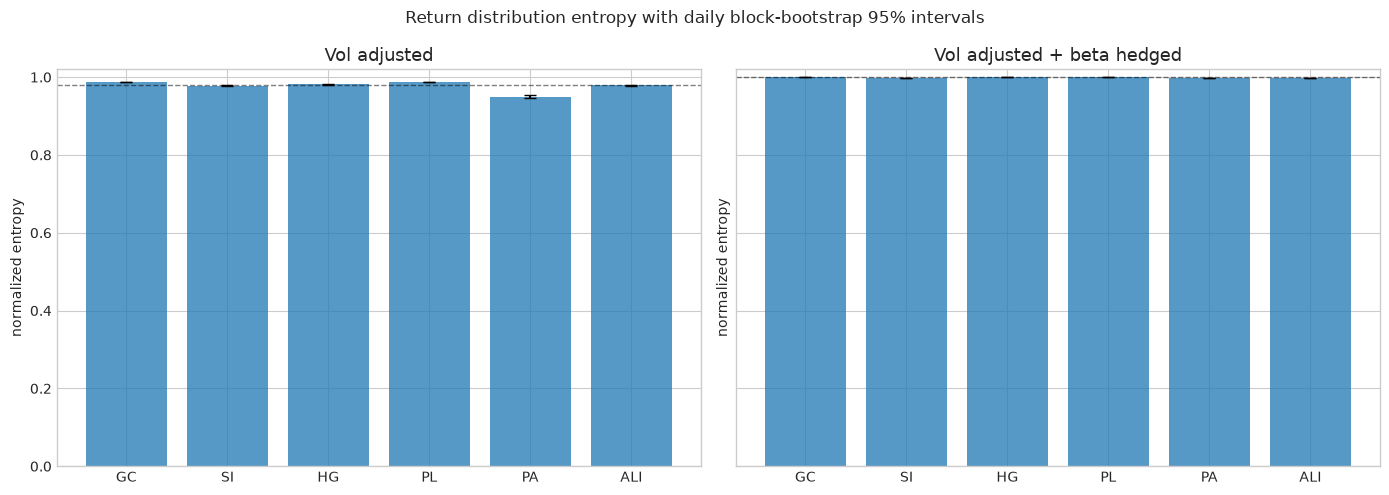

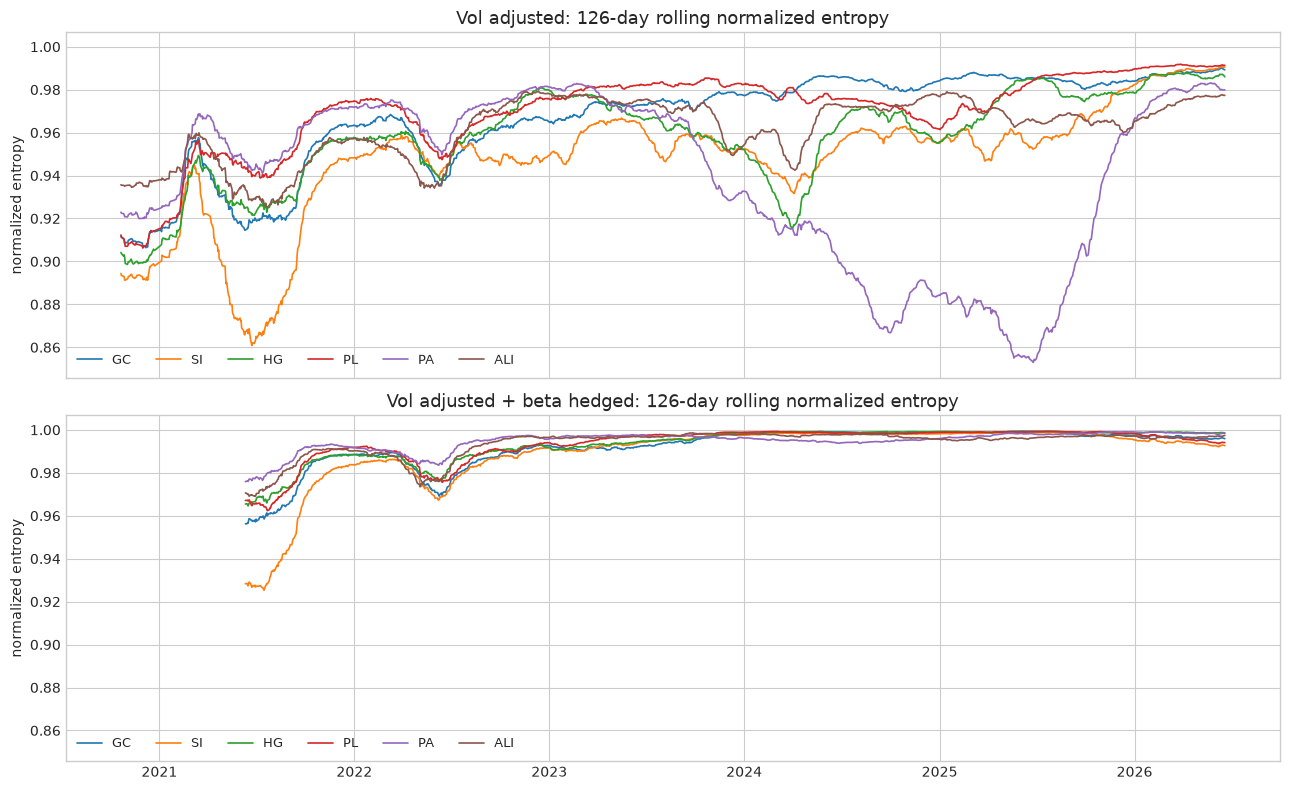

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, (panel_name, diag) in zip(axes, diagnostics.items(), strict=True):
    summary = diag["entropy_summary"].loc[ROOTS]
    values = summary["normalized_entropy"]
    ci_low = np.minimum(summary["normalized_entropy_ci_low"], values)
    ci_high = np.maximum(summary["normalized_entropy_ci_high"], values)
    lower = np.maximum(0.0, values - ci_low)
    upper = np.maximum(0.0, ci_high - values)
    axis.bar(ROOTS, values, color="tab:blue", alpha=0.75)
    axis.errorbar(
        ROOTS, values, yerr=np.vstack([lower, upper]), fmt="none", color="black", capsize=4
    )
    axis.set_title(panel_name)
    axis.set_ylim(0.0, 1.02)
    axis.set_ylabel("normalized entropy")
    axis.axhline(values.median(), color="black", linewidth=1, linestyle="--", alpha=0.5)
fig.suptitle("Return distribution entropy with daily block-bootstrap 95% intervals")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, sharey=True)
for axis, (panel_name, diag) in zip(axes, diagnostics.items(), strict=True):
    rolling = diag["rolling_entropy"]
    for root in ROOTS:
        axis.plot(rolling.index, rolling[root], linewidth=1.2, label=root)
    axis.set_title(f"{panel_name}: {ROLLING_ENTROPY_DAYS}-day rolling normalized entropy")
    axis.set_ylabel("normalized entropy")
    axis.legend(ncol=6, loc="lower left")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

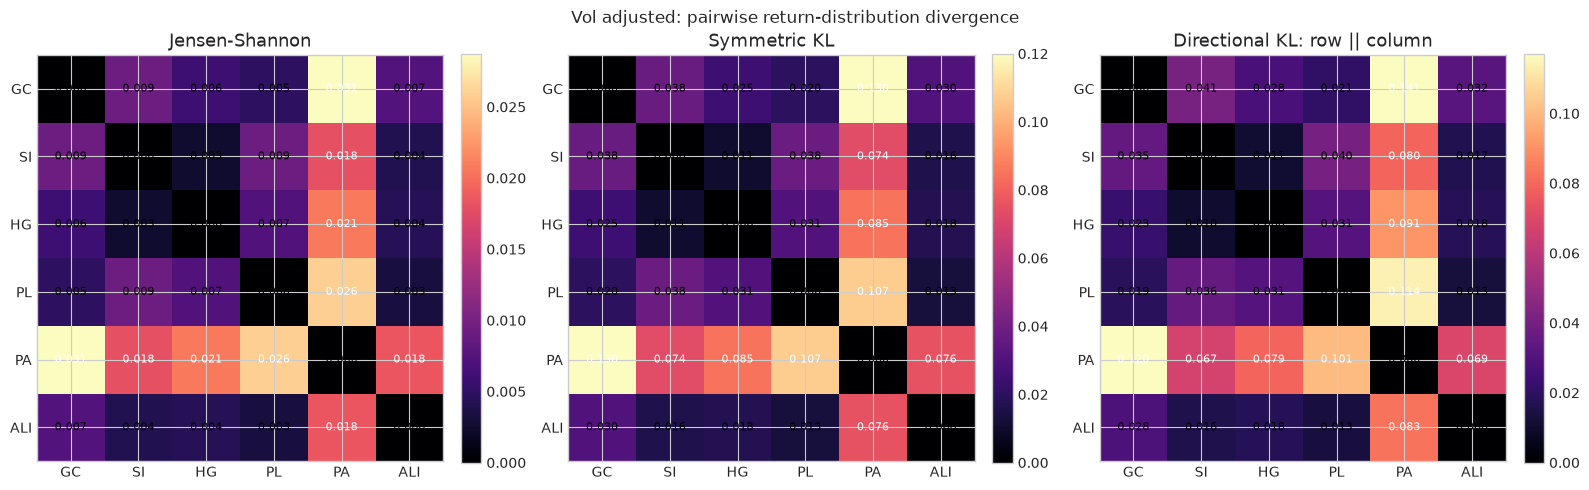

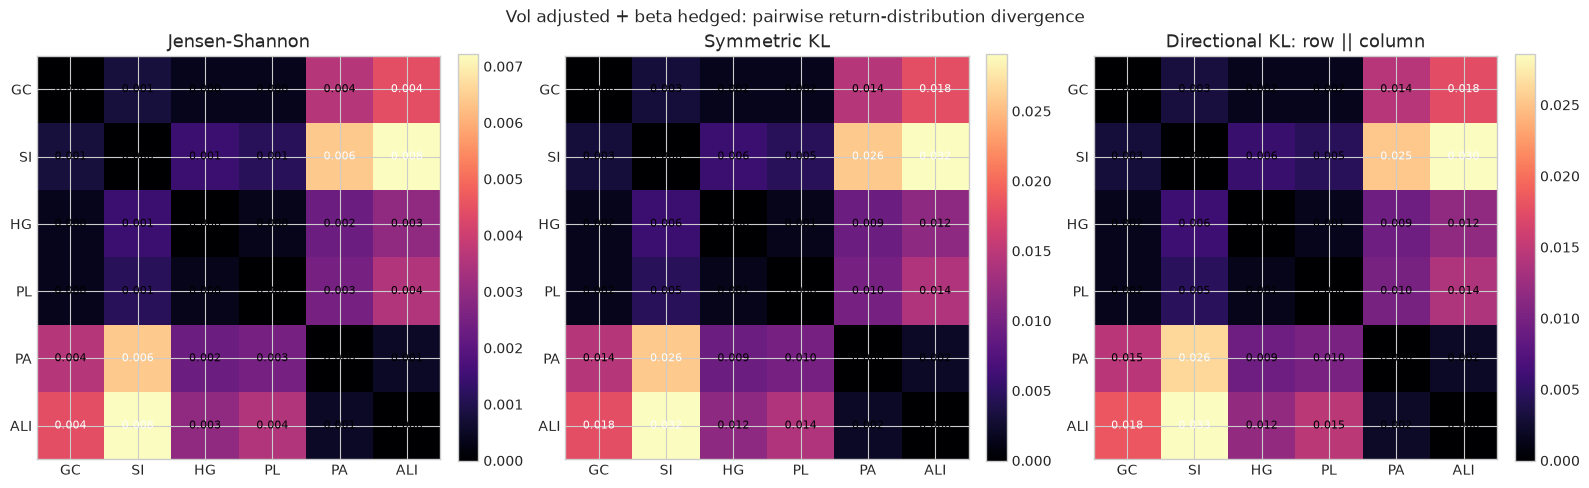

In [19]:
def plot_matrix_heatmaps(panel_name: str, diag: dict[str, object]) -> None:
    heatmaps = [
        ("Jensen-Shannon", diag["matrices"]["js"]),
        ("Symmetric KL", diag["matrices"]["symmetric_kl"]),
        ("Directional KL: row || column", diag["matrices"]["directional_kl"]),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for axis, (title, matrix) in zip(axes, heatmaps, strict=True):
        values = matrix.loc[ROOTS, ROOTS].to_numpy(dtype=float)
        vmax = np.nanquantile(values[~np.eye(len(ROOTS), dtype=bool)], 0.95)
        image = axis.imshow(values, cmap="magma", vmin=0.0, vmax=vmax)
        axis.set_xticks(range(len(ROOTS)))
        axis.set_xticklabels(ROOTS)
        axis.set_yticks(range(len(ROOTS)))
        axis.set_yticklabels(ROOTS)
        axis.set_title(title)
        for row_idx in range(len(ROOTS)):
            for col_idx in range(len(ROOTS)):
                text_color = "white" if values[row_idx, col_idx] > vmax * 0.55 else "black"
                axis.text(
                    col_idx,
                    row_idx,
                    f"{values[row_idx, col_idx]:.3f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=8,
                )
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    fig.suptitle(f"{panel_name}: pairwise return-distribution divergence")
    fig.tight_layout()
    plt.show()


for panel_name, diag in diagnostics.items():
    plot_matrix_heatmaps(panel_name, diag)

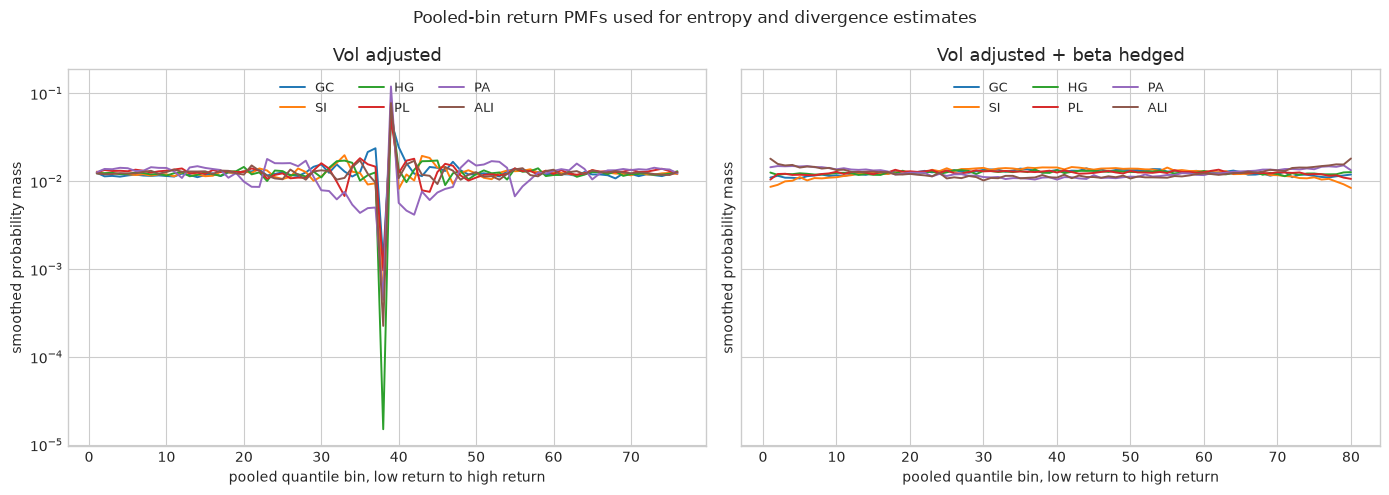

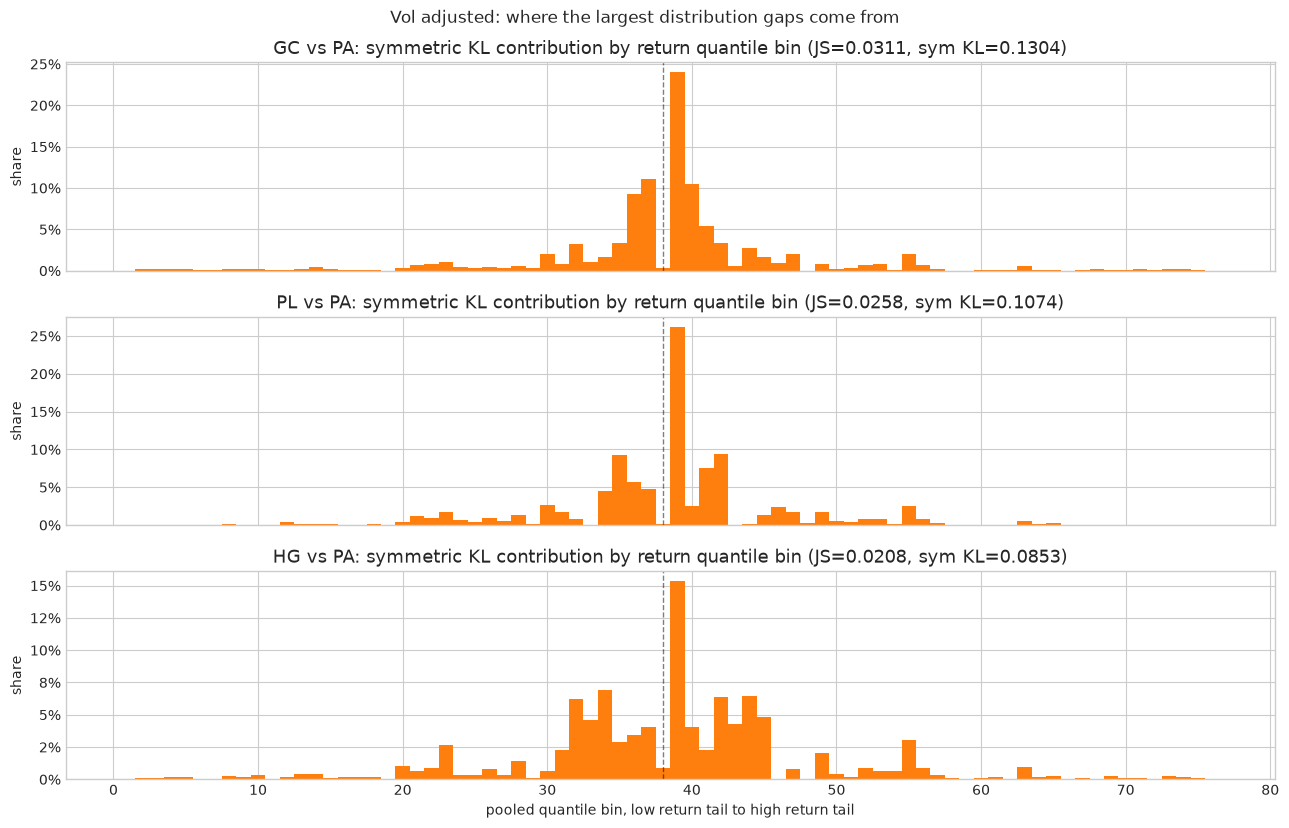

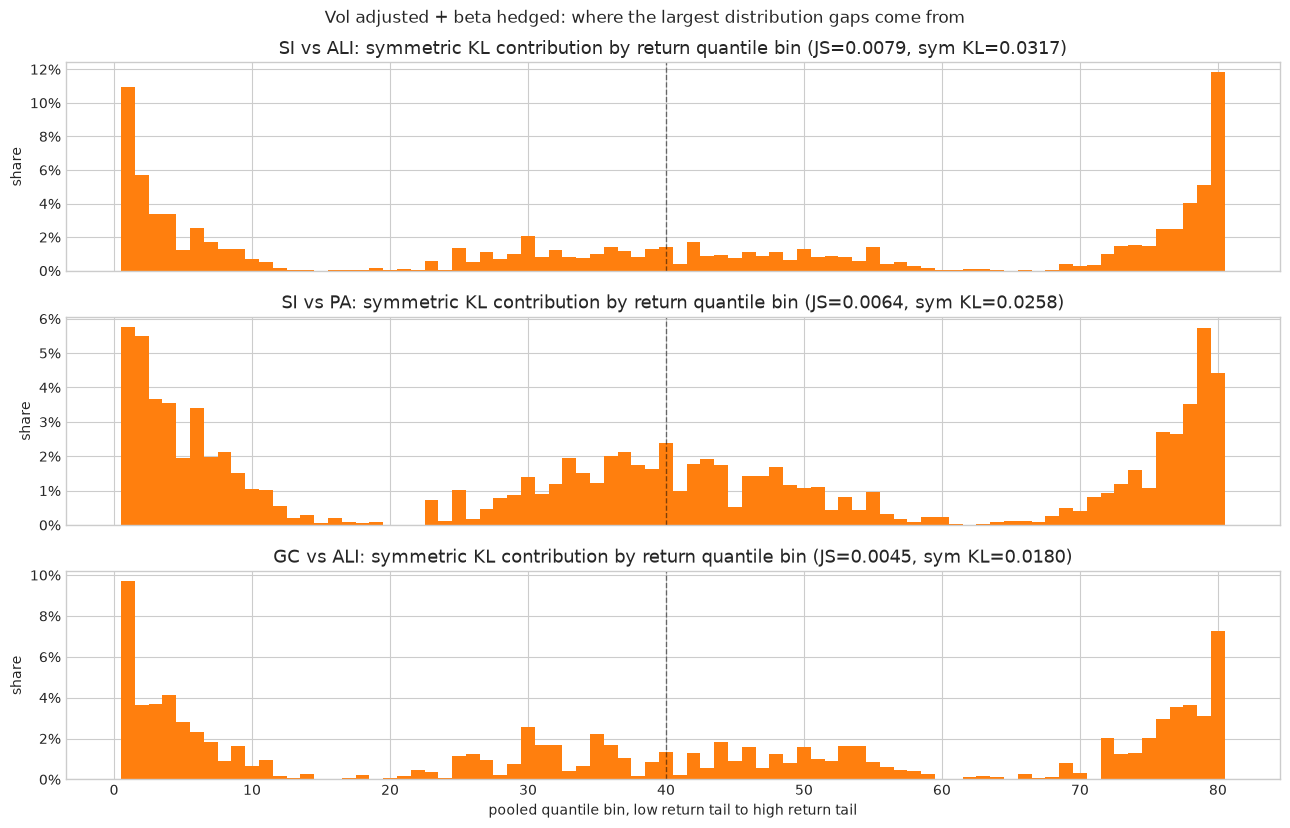

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, (panel_name, diag) in zip(axes, diagnostics.items(), strict=True):
    for root in ROOTS:
        axis.plot(
            np.arange(1, len(diag["pmfs"][root]) + 1),
            diag["pmfs"][root],
            linewidth=1.4,
            label=root,
        )
    axis.set_yscale("log")
    axis.set_title(panel_name)
    axis.set_xlabel("pooled quantile bin, low return to high return")
    axis.set_ylabel("smoothed probability mass")
    axis.legend(ncol=3, loc="upper center")
fig.suptitle("Pooled-bin return PMFs used for entropy and divergence estimates")
fig.tight_layout()
plt.show()


def plot_top_divergence_contributions(panel_name: str, diag: dict[str, object]) -> None:
    top_pairs = diag["divergence_summary"].head(TOP_DIVERGENCE_PAIRS)
    fig, axes = plt.subplots(
        TOP_DIVERGENCE_PAIRS, 1, figsize=(13, 2.8 * TOP_DIVERGENCE_PAIRS), sharex=True
    )
    if TOP_DIVERGENCE_PAIRS == 1:
        axes = [axes]
    for axis, (_, row) in zip(axes, top_pairs.iterrows(), strict=True):
        left = row["asset_a"]
        right = row["asset_b"]
        p = diag["pmfs"][left]
        q = diag["pmfs"][right]
        contribution = 0.5 * (p - q) * np.log(p / q)
        contribution_share = contribution / contribution.sum()
        axis.bar(
            np.arange(1, len(contribution_share) + 1),
            contribution_share,
            width=1.0,
            color="tab:orange",
        )
        axis.axvline(
            len(contribution_share) / 2, color="black", linestyle="--", linewidth=1, alpha=0.5
        )
        axis.set_title(
            f"{left} vs {right}: symmetric KL contribution by return quantile bin "
            f"(JS={row['js']:.4f}, sym KL={row['symmetric_kl']:.4f})"
        )
        axis.set_ylabel("share")
        axis.yaxis.set_major_formatter(lambda value, _pos: f"{value:.0%}")
    axes[-1].set_xlabel("pooled quantile bin, low return tail to high return tail")
    fig.suptitle(f"{panel_name}: where the largest distribution gaps come from")
    fig.tight_layout()
    plt.show()


for panel_name, diag in diagnostics.items():
    plot_top_divergence_contributions(panel_name, diag)